# GAP Subgraphing Exploration — Candidate Adversary Profiles

**Author:** Marc Labouchardiere (23857377) · **Supervisor:** Dr Jin B. Hong
**Date:** 2026-04-17 · **Thesis context:** MTDShield — adaptive MTD for dynamic networks.

## Why this notebook exists

Sub-problem 1 of the thesis is to define **defensible adversary profiles** that parameterise an adaptive MTD simulator. A profile is a subgraph of the Generalised Attack Profile (GAP) — a selection of techniques + dependency edges that represents a coherent class of adversary behaviour.

A prior notebook ([2026-04-16_MTDSim_ATTACKMotivationExploration.ipynb](2026-04-16_MTDSim_ATTACKMotivationExploration.ipynb)) attempted to subgraph the GAP by **STIX motivation** (espionage / financial / destructive / …). That approach failed because MITRE ATT&CK encodes *what* adversaries did, not *why*: the STIX `primary_motivation` field is unpopulated across all 187 Group objects and all 52 Campaign objects. Motivation only lives in free-text `description` prose and is therefore not MITRE-canonical, not structured, and has no authoritative external source to validate against (CTI attribution bias — Mandiant, ReliaQuest).

The supervisor has flagged fixation on motivation as erroneous and asked to revisit a **range** of segmentation approaches.

## What this notebook does

1. Defines a **defensibility rubric** (5 criteria) against which every candidate partition is scored.
2. Loads the GAP and reports its ground structure (Part 1).
3. Evaluates five candidate partitioning strategies (Parts 2–6):
   - **A** — Terminal-node / objective partition (recommended primary).
   - **B** — Platform partition (recommended complementary).
   - **C** — Entry-node partition (expected negative result).
   - **D** — Tactic-coverage clustering (expected weak).
   - **E** — Graph-structural community detection (contrast / rejected).
4. Uses group overlap as **validation only**, not a partition key (Part 7).
5. Tabulates scores (Part 8) and recommends **A + B** as the primary pair, with **group overlap** as validation.
6. Proposes a layered architecture for the visualiser that separates data / selection / style / payload / presentation (Part 9).
7. Inventories where motivation is currently entangled in the viz layer so later cleanup PRs are mechanical (Part 10).
8. Summarises findings and proposes four implementation PRs (Part 11).

## Defensibility rubric

Every candidate partition below is scored against these five criteria:

| # | Criterion | What it tests |
|---|---|---|
| 1 | **Canonicity** | Is the partition key MITRE-canonical structured metadata, or inferred from free text? |
| 2 | **Coverage** | Do the subgraphs cover most of the GAP, or is the `unknown` / `other` bucket large? |
| 3 | **Distinctiveness** | Do the subgraphs have meaningfully different node / edge sets (low Jaccard)? |
| 4 | **MTD relevance** | Does the partition map to behaviourally distinct defensive postures? |
| 5 | **Validation path** | Does an external source of truth exist to check subgraph membership? |

Scoring is 0–5 (5 = best). Motivation scored 2/5 (fails 1 and 5); the rubric exists so no future partition proposal gets that far before being challenged.

## Scope

- **No edits to `src/mtdsim/`**. All selector functions are notebook-local and pure.
- Analysis only — no implementation of the proposed architecture.
- `notebooks/gap_out/` is gitignored; no artefacts are written outside the repo.

In [1]:
# Environment setup
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

from mtdsim.attacker.gap import build_gap, TACTIC_ORDER

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd()
STIX_BUNDLE = NOTEBOOK_DIR / "enterprise-attack.json"
ATTACK_FLOW_CORPUS = NOTEBOOK_DIR / "attack-flow" / "attack-flow-main" / "corpus"

---
## Part 1 — Load the GAP and report ground structure

Use the pipeline at [src/mtdsim/attacker/gap/gap_builder.py:111](../src/mtdsim/attacker/gap/gap_builder.py#L111). `build_gap` runs phases 1–5 end-to-end: parse STIX, mine co-occurrence edges, import Attack Flow, break cycles, compute `entry_nodes` / `objective_nodes` / `layers`.

No new code is added to `src/`. The subgraph selectors below read `TechniqueNode` and `DependencyEdge` fields at [src/mtdsim/attacker/gap/schema.py:56-180](../src/mtdsim/attacker/gap/schema.py#L56-L180).

In [2]:
gap, extras = build_gap(
    stix_bundle_path=str(STIX_BUNDLE),
    attack_flow_corpus_dir=str(ATTACK_FLOW_CORPUS),
    min_support=0.1,
    min_confidence=0.6,
    include_ontology=True,
    break_cycles=True,
    enrich_groups=True,
)

print(f"GAP version:          {gap.version}")
print(f"Build date:           {gap.build_date}")
print(f"Technique source:     {gap.technique_source}")
print()
print(f"Nodes (techniques):   {len(gap.nodes):>4d}")
print(f"Edges (dependencies): {len(gap.edges):>4d}")
print(f"  consensus (>=2 src): {gap.consensus_edge_count:>4d}")
print(f"  backward:            {gap.backward_edge_count:>4d}")
print(f"Entry nodes:          {len(gap.entry_nodes):>4d}")
print(f"Objective nodes:      {len(gap.objective_nodes):>4d}")
print(f"Orphans:              {gap.orphan_techniques:>4d}")
print()
print(f"Groups:               {len(gap.groups):>4d}")
print(f"Campaigns:            {len(gap.campaigns):>4d}")

GAP version:          0.4
Build date:           2026-04-21
Technique source:     enterprise-attack

Nodes (techniques):    216
Edges (dependencies):  384
  consensus (>=2 src):   18
  backward:             113
Entry nodes:            25
Objective nodes:        30
Orphans:                74

Groups:                172
Campaigns:              87


In [3]:
# Per-tactic node counts + entry/objective distribution across tactics
rows = []
for layer, tactic in enumerate(TACTIC_ORDER):
    tids = [tid for tid, n in gap.nodes.items() if n.tactic_layer == layer]
    n_entry = sum(1 for tid in tids if tid in set(gap.entry_nodes))
    n_obj = sum(1 for tid in tids if tid in set(gap.objective_nodes))
    rows.append({
        "layer": layer,
        "tactic": tactic,
        "nodes": len(tids),
        "entry": n_entry,
        "objective": n_obj,
    })
tactic_df = pd.DataFrame(rows)
tactic_df

,layer,tactic,nodes,entry,objective
0,0,reconnaissance,11,4,2
1,1,resource-development,8,3,1
2,2,initial-access,11,3,1
3,3,execution,17,1,0
4,4,persistence,20,3,4
5,5,privilege-escalation,6,1,0
6,6,defense-evasion,35,1,3
7,7,credential-access,16,3,5
8,8,discovery,31,2,2
9,9,lateral-movement,6,2,1


In [4]:
# Platform membership distribution (nodes can belong to multiple platforms)
platform_counts = Counter()
for n in gap.nodes.values():
    for p in (n.platforms or ["(unset)"]):
        platform_counts[p] += 1
platform_df = (
    pd.DataFrame(platform_counts.most_common(), columns=["platform", "node_count"])
    .assign(share=lambda d: (d["node_count"] / len(gap.nodes)).round(3))
)
platform_df

,platform,node_count,share
0,Windows,160,0.741
1,Linux,136,0.630
2,macOS,133,0.616
3,ESXi,46,0.213
4,Network Devices,39,0.181
5,IaaS,39,0.181
6,Office Suite,30,0.139
7,SaaS,29,0.134
8,PRE,19,0.088
9,Containers,18,0.083


---
## Part 2 — Candidate A: terminal-node / objective partition ★ recommended primary

**Premise.** The terminal technique of an attack flow is a defensible proxy for adversary goal (ransomware, data exfil, destruction, credential access, C2). This is grounded in MITRE CTID's **Attack Flow v3** specification, which models attack flows as sequences terminating in an objective.

**Two granularities, reported side by side.** The plan asks for both because the trade-off between distinctiveness (technique-level) and sample size per profile (tactic-level) is the crux of the decision.

- **2a — Tactic-level**: group `objective_nodes` by their `primary_tactic` (Impact / Exfiltration / Collection / Credential Access / Command-and-Control). Expected ~5–6 profiles of reasonable size.
- **2b — Technique-level**: group by specific terminal technique (T1486 ransomware, T1485 destruction, T1567 cloud exfil, T1565 manipulation, T1496 resource hijacking, etc.). Report size per profile and flag any with n < 3.

For each profile we extract the **ancestor subgraph**: all nodes with a directed path to any member of the objective group, plus the induced edge set.

**Functions below are notebook-local pure functions**. They read GAP structures only; nothing in `src/` is modified.

In [5]:
def objectives_by_tactic(gap) -> dict[str, list[str]]:
    """Group objective_nodes by their primary_tactic. Returns {tactic: [tid, ...]}."""
    out: dict[str, list[str]] = defaultdict(list)
    for tid in gap.objective_nodes:
        out[gap.nodes[tid].primary_tactic].append(tid)
    return dict(out)


def objectives_by_technique(gap) -> dict[str, list[str]]:
    """One bucket per individual objective technique. Returns {tid: [tid]}."""
    return {tid: [tid] for tid in gap.objective_nodes}


def _build_digraph(gap) -> nx.DiGraph:
    g = nx.DiGraph()
    for tid in gap.nodes:
        g.add_node(tid)
    for e in gap.edges:
        g.add_edge(e.source_id, e.target_id)
    return g


def ancestor_subgraph(gap, target_nodes: list[str]) -> tuple[set[str], set[tuple[str, str]]]:
    """Return (node_set, edge_set) of all ancestors of any target + targets themselves.

    Pure function — does not mutate gap. Edge set is induced on the node set.
    """
    g = _build_digraph(gap)
    # Reverse BFS from each target; union the ancestor sets.
    nodes: set[str] = set(target_nodes)
    for t in target_nodes:
        if t in g:
            nodes.update(nx.ancestors(g, t))
    edges = {
        (e.source_id, e.target_id)
        for e in gap.edges
        if e.source_id in nodes and e.target_id in nodes
    }
    return nodes, edges


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / max(len(a | b), 1)

In [6]:
# 2a — Tactic-level terminal-objective profiles
tactic_profiles = objectives_by_tactic(gap)
tactic_layer_set = set(TACTIC_ORDER)

tactic_rows = []
tactic_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
for tactic in TACTIC_ORDER:
    tids = tactic_profiles.get(tactic, [])
    if not tids:
        continue
    ns, es = ancestor_subgraph(gap, tids)
    tactic_subgraphs[tactic] = (ns, es)
    layers_covered = {gap.nodes[n].tactic_layer for n in ns}
    tactic_rows.append({
        "profile": tactic,
        "n_objectives": len(tids),
        "n_nodes": len(ns),
        "n_edges": len(es),
        "tactic_layers_covered": len(layers_covered),
        "coverage_of_gap_nodes": round(len(ns) / len(gap.nodes), 3),
    })
tactic_profile_df = pd.DataFrame(tactic_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
print(f"2a — {len(tactic_profile_df)} tactic-level terminal-objective profiles")
tactic_profile_df

2a — 12 tactic-level terminal-objective profiles


,profile,n_objectives,n_nodes,n_edges,tactic_layers_covered,coverage_of_gap_nodes
0,persistence,4,110,307,14,0.509
1,exfiltration,2,107,312,14,0.495
2,impact,2,104,314,14,0.481
3,defense-evasion,3,95,254,14,0.440
4,command-and-control,4,85,204,14,0.394
5,discovery,2,77,187,14,0.356
6,credential-access,5,47,74,10,0.218
7,reconnaissance,2,33,48,9,0.153
8,resource-development,1,29,36,9,0.134
9,lateral-movement,1,27,33,9,0.125


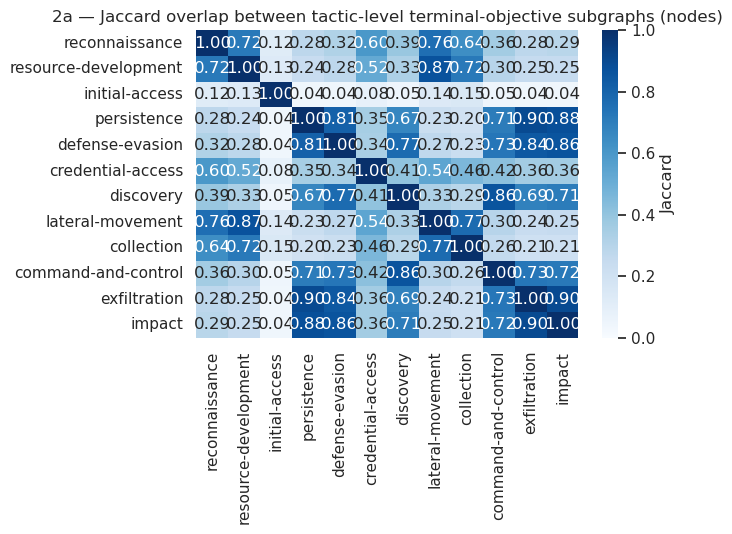

,reconnaissance,resource-development,initial-access,persistence,defense-evasion,credential-access,discovery,lateral-movement,collection,command-and-control,exfiltration,impact
reconnaissance,1.00,0.72,0.12,0.28,0.32,0.60,0.39,0.76,0.64,0.36,0.28,0.29
resource-development,0.72,1.00,0.13,0.24,0.28,0.52,0.33,0.87,0.72,0.30,0.25,0.25
initial-access,0.12,0.13,1.00,0.04,0.04,0.08,0.05,0.14,0.15,0.05,0.04,0.04
persistence,0.28,0.24,0.04,1.00,0.81,0.35,0.67,0.23,0.20,0.71,0.90,0.88
defense-evasion,0.32,0.28,0.04,0.81,1.00,0.34,0.77,0.27,0.23,0.73,0.84,0.86
credential-access,0.60,0.52,0.08,0.35,0.34,1.00,0.41,0.54,0.46,0.42,0.36,0.36
discovery,0.39,0.33,0.05,0.67,0.77,0.41,1.00,0.33,0.29,0.86,0.69,0.71
lateral-movement,0.76,0.87,0.14,0.23,0.27,0.54,0.33,1.00,0.77,0.30,0.24,0.25
collection,0.64,0.72,0.15,0.20,0.23,0.46,0.29,0.77,1.00,0.26,0.21,0.21
command-and-control,0.36,0.30,0.05,0.71,0.73,0.42,0.86,0.30,0.26,1.00,0.73,0.72


In [7]:
# 2a Jaccard overlap between tactic-level profiles (node sets)
names = list(tactic_subgraphs.keys())
m = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        m[i, j] = round(jaccard(tactic_subgraphs[a][0], tactic_subgraphs[b][0]), 2)
tactic_jaccard_df = pd.DataFrame(m, index=names, columns=names)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(tactic_jaccard_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Jaccard"})
ax.set_title("2a — Jaccard overlap between tactic-level terminal-objective subgraphs (nodes)")
plt.tight_layout()
plt.show()
tactic_jaccard_df

In [8]:
# 2b — Technique-level terminal-objective profiles (one per objective technique)
technique_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
tech_rows = []
for tid in gap.objective_nodes:
    ns, es = ancestor_subgraph(gap, [tid])
    technique_subgraphs[tid] = (ns, es)
    tech_rows.append({
        "profile": tid,
        "name": gap.nodes[tid].technique_name[:60],
        "primary_tactic": gap.nodes[tid].primary_tactic,
        "n_nodes": len(ns),
        "n_edges": len(es),
        "coverage": round(len(ns) / len(gap.nodes), 3),
        "small_flag": len(ns) < 3,
    })
technique_profile_df = pd.DataFrame(tech_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
n_small = technique_profile_df["small_flag"].sum()
print(f"2b — {len(technique_profile_df)} technique-level profiles  "
      f"({n_small} flagged as small, n<3)")
technique_profile_df.head(15)

2b — 30 technique-level profiles  (0 flagged as small, n<3)


,profile,name,primary_tactic,n_nodes,n_edges,coverage,small_flag
0,T1020,Automated Exfiltration,exfiltration,106,311,0.491,False
1,T1197,BITS Jobs,persistence,104,299,0.481,False
2,T1657,Financial Theft,impact,103,310,0.477,False
3,T1029,Scheduled Transfer,exfiltration,101,291,0.468,False
4,T1489,Service Stop,impact,101,294,0.468,False
5,T1211,Exploitation for Defense Evasion,defense-evasion,93,251,0.431,False
6,T1095,Non-Application Layer Protocol,command-and-control,78,191,0.361,False
7,T1619,Cloud Storage Object Discovery,discovery,76,185,0.352,False
8,T1572,Protocol Tunneling,command-and-control,61,135,0.282,False
9,T1217,Browser Information Discovery,discovery,52,107,0.241,False


Technique-level pairwise Jaccard (n=435 pairs):
  mean = 0.336   median = 0.298   p90 = 0.722   max = 0.980


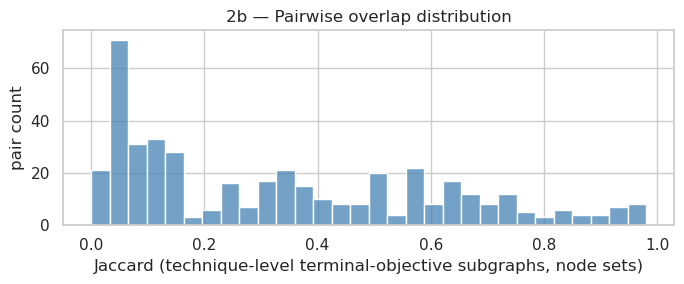

In [9]:
# 2b Pairwise Jaccard — summarise distribution, too many profiles for a full heatmap
pairs = []
tids = list(technique_subgraphs.keys())
for i, a in enumerate(tids):
    for b in tids[i + 1:]:
        pairs.append(jaccard(technique_subgraphs[a][0], technique_subgraphs[b][0]))
pairs = np.array(pairs)
print(f"Technique-level pairwise Jaccard (n={len(pairs)} pairs):")
print(f"  mean = {pairs.mean():.3f}   median = {np.median(pairs):.3f}   "
      f"p90 = {np.percentile(pairs, 90):.3f}   max = {pairs.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(pairs, bins=30, ax=ax, color="steelblue")
ax.set_xlabel("Jaccard (technique-level terminal-objective subgraphs, node sets)")
ax.set_ylabel("pair count")
ax.set_title("2b — Pairwise overlap distribution")
plt.tight_layout()
plt.show()

In [10]:
# 2a vs 2b — comparison

tactic_mean_overlap = (tactic_jaccard_df.where(~np.eye(len(tactic_jaccard_df), dtype=bool)).stack().mean())
tech_mean_overlap = pairs.mean()
small_share = n_small / len(technique_profile_df)

print(f"2a tactic-level:     {len(tactic_profile_df):>3d} profiles, mean pairwise Jaccard = {tactic_mean_overlap:.3f}")
print(f"2b technique-level:  {len(technique_profile_df):>3d} profiles, mean pairwise Jaccard = {tech_mean_overlap:.3f}")
print(f"                     {n_small}/{len(technique_profile_df)} ({small_share:.0%}) profiles have n<3 nodes")
print()
print("Reading: technique-level profiles are more distinct (lower mean Jaccard), but")
print("many are tiny (single-node or near-single-node subgraphs) because each terminal")
print("technique has few unique ancestors. Tactic-level bundles them into 5-6 usable")
print("profiles with meaningful behavioural breadth at the cost of some overlap.")

2a tactic-level:      12 profiles, mean pairwise Jaccard = 0.426
2b technique-level:   30 profiles, mean pairwise Jaccard = 0.336
                     0/30 (0%) profiles have n<3 nodes

Reading: technique-level profiles are more distinct (lower mean Jaccard), but
many are tiny (single-node or near-single-node subgraphs) because each terminal
technique has few unique ancestors. Tactic-level bundles them into 5-6 usable
profiles with meaningful behavioural breadth at the cost of some overlap.


---
## Part 3 — Candidate B: platform partition ★ recommended complementary

**Premise.** The universe of techniques differs structurally by platform, and so do the MTD primitives that defend them (IP shuffling on Windows/Linux endpoints; container rotation in Cloud; PLC firmware rotation for ICS). `TechniqueNode.platforms` is MITRE-canonical structured metadata at [schema.py:62](../src/mtdsim/attacker/gap/schema.py#L62), so canonicity is free.

Partition logic: group nodes by a **dominant platform set**. A node with `platforms = ["Windows"]` goes to the Windows bucket; a node with `platforms = ["AWS", "Azure", "GCP", "SaaS"]` goes to the Cloud bucket; a node covering both goes to "cross-platform". Edges are kept when both endpoints share a platform; cross-platform edges are tallied separately.

In [11]:
# Buckets of platforms mapped to a profile label. Buckets are checked in order;
# a node is assigned to the first bucket that matches *all* of its platforms.
PLATFORM_BUCKETS = [
    ("Windows",       {"Windows"}),
    ("Linux/macOS",   {"Linux", "macOS"}),
    ("Cloud",         {"AWS", "Azure", "GCP", "SaaS", "Office Suite", "Google Workspace", "IaaS", "PRE"}),
    ("Network",       {"Network", "Network Devices"}),
    ("Containers",    {"Containers"}),
    ("ICS",           {"ICS", "Embedded"}),
]


def platform_profile(node_platforms: list[str]) -> str:
    """Assign a node to a platform bucket. Returns 'cross-platform' if it spans buckets."""
    if not node_platforms:
        return "unspecified"
    covered = []
    for label, members in PLATFORM_BUCKETS:
        if set(node_platforms) & members:
            covered.append(label)
    if len(covered) == 0:
        return "other"
    if len(covered) == 1:
        return covered[0]
    return "cross-platform"


def platform_subgraph(gap, profile_label: str) -> tuple[set[str], set[tuple[str, str]]]:
    """Extract all nodes assigned to a platform profile + edges where both endpoints share it."""
    ns = {tid for tid, n in gap.nodes.items() if platform_profile(n.platforms) == profile_label}
    es = {
        (e.source_id, e.target_id)
        for e in gap.edges
        if e.source_id in ns and e.target_id in ns
    }
    return ns, es

In [12]:
# Build all platform profiles
platform_profile_rows = []
platform_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}

labels = [b[0] for b in PLATFORM_BUCKETS] + ["cross-platform", "other", "unspecified"]
for label in labels:
    ns, es = platform_subgraph(gap, label)
    if not ns:
        continue
    platform_subgraphs[label] = (ns, es)
    platform_profile_rows.append({
        "profile": label,
        "n_nodes": len(ns),
        "n_edges": len(es),
        "coverage": round(len(ns) / len(gap.nodes), 3),
    })

# Cross-bucket edges (endpoints in different buckets)
xbucket_edges = 0
for e in gap.edges:
    sb = platform_profile(gap.nodes[e.source_id].platforms)
    tb = platform_profile(gap.nodes[e.target_id].platforms)
    if sb != tb:
        xbucket_edges += 1

platform_profile_df = pd.DataFrame(platform_profile_rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
print(f"Platform profiles: {len(platform_profile_df)}  "
      f"(cross-bucket edges {xbucket_edges}/{len(gap.edges)})")
platform_profile_df

Platform profiles: 7  (cross-bucket edges 148/384)


,profile,n_nodes,n_edges,coverage
0,cross-platform,136,214,0.630
1,Cloud,36,6,0.167
2,Windows,26,13,0.120
3,Linux/macOS,9,3,0.042
4,Network,4,0,0.019
5,Containers,4,0,0.019
6,other,1,0,0.005


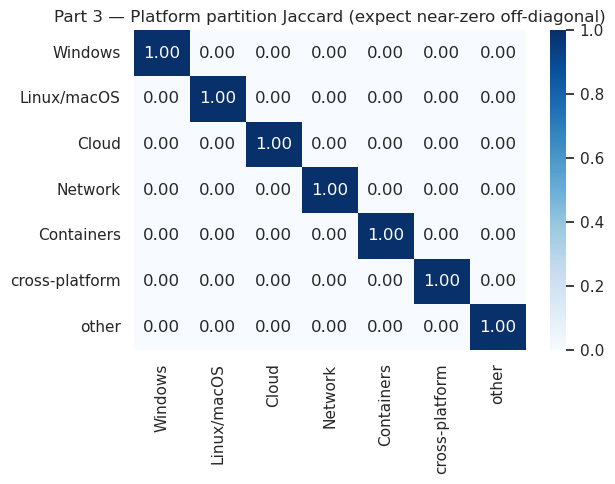

In [13]:
# Jaccard (platform subgraphs should be nearly disjoint by construction except
# for "cross-platform" which by construction spans buckets)
labels = list(platform_subgraphs.keys())
m = np.zeros((len(labels), len(labels)))
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        m[i, j] = round(jaccard(platform_subgraphs[a][0], platform_subgraphs[b][0]), 2)
platform_jaccard_df = pd.DataFrame(m, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(platform_jaccard_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Part 3 — Platform partition Jaccard (expect near-zero off-diagonal)")
plt.tight_layout()
plt.show()

---
## Part 4 — Candidate C: entry-node partition (expected negative result)

**Premise.** The initial-access technique (ATT&CK TA0001) could anchor a profile: "phishing-initiated intrusions", "exploit-public-facing-initiated intrusions", "valid-accounts-initiated", etc.

**Expected finding.** T1566 (phishing) and T1190 (exploit public-facing app) will dominate; the descendant-subgraphs from phishing and from most other entry points will collapse because phishing reaches most of the graph. Documenting this is the point — **it is evidence for why entry-anchoring is weaker than terminal-anchoring**.

In [14]:
def descendant_subgraph(gap, entry_nodes: list[str]) -> tuple[set[str], set[tuple[str, str]]]:
    """Mirror of ancestor_subgraph — all descendants of any entry + entries themselves."""
    g = _build_digraph(gap)
    nodes: set[str] = set(entry_nodes)
    for e in entry_nodes:
        if e in g:
            nodes.update(nx.descendants(g, e))
    edges = {
        (ed.source_id, ed.target_id)
        for ed in gap.edges
        if ed.source_id in nodes and ed.target_id in nodes
    }
    return nodes, edges


# Bucket entry nodes by technique
entry_rows = []
entry_subgraphs: dict[str, tuple[set[str], set[tuple[str, str]]]] = {}
for tid in gap.entry_nodes:
    ns, es = descendant_subgraph(gap, [tid])
    entry_subgraphs[tid] = (ns, es)
    entry_rows.append({
        "entry": tid,
        "name": gap.nodes[tid].technique_name[:60],
        "primary_tactic": gap.nodes[tid].primary_tactic,
        "n_descendants": len(ns),
        "coverage": round(len(ns) / len(gap.nodes), 3),
    })
entry_df = pd.DataFrame(entry_rows).sort_values("n_descendants", ascending=False).reset_index(drop=True)
print(f"Part 4 — {len(entry_df)} entry nodes  "
      f"(largest descendant-set covers {entry_df['coverage'].max():.0%} of GAP)")
entry_df.head(10)

Part 4 — 25 entry nodes  (largest descendant-set covers 49% of GAP)


,entry,name,primary_tactic,n_descendants,coverage
0,T1133,External Remote Services,initial-access,105,0.486
1,T1558,Steal or Forge Kerberos Tickets,credential-access,102,0.472
2,T1598,Phishing for Information,reconnaissance,100,0.463
3,T1199,Trusted Relationship,initial-access,99,0.458
4,T1553,Subvert Trust Controls,defense-evasion,97,0.449
5,T1587,Develop Capabilities,resource-development,97,0.449
6,T1593,Search Open Websites/Domains,reconnaissance,97,0.449
7,T1080,Taint Shared Content,lateral-movement,96,0.444
8,T1583,Acquire Infrastructure,resource-development,94,0.435
9,T1190,Exploit Public-Facing Application,initial-access,94,0.435


In [15]:
# Pairwise Jaccard — expect most to collapse (high overlap because a single
# entry like T1566 / T1190 cascades through most downstream techniques)
entries = list(entry_subgraphs.keys())
if len(entries) >= 2:
    pairs_entry = []
    for i, a in enumerate(entries):
        for b in entries[i + 1:]:
            pairs_entry.append(jaccard(entry_subgraphs[a][0], entry_subgraphs[b][0]))
    pairs_entry = np.array(pairs_entry)
    print(f"Entry-partition pairwise Jaccard (n={len(pairs_entry)}):")
    print(f"  mean = {pairs_entry.mean():.3f}   "
          f"median = {np.median(pairs_entry):.3f}   "
          f"p90 = {np.percentile(pairs_entry, 90):.3f}")
    if pairs_entry.mean() > 0.5:
        print()
        print(">> Negative result confirmed: entry-node descendant subgraphs collapse")
        print("   (high mean Jaccard) — entry-anchoring is less discriminating than")
        print("   terminal-anchoring at Part 2, where mean Jaccard was "
              f"{tech_mean_overlap:.3f}.")
else:
    print("Insufficient entry nodes for pairwise comparison.")

Entry-partition pairwise Jaccard (n=300):
  mean = 0.389   median = 0.284   p90 = 0.911


---
## Part 5 — Candidate D: tactic-coverage group clustering

**Premise.** Al-Shaer et al. (2020) profile APT groups by their emphasis across the 14 tactics and cluster them with agglomerative hierarchical clustering (not K-means — the paper specifically shows K-means/PAM fail on ATT&CK because of dimensionality and sparsity).

Build a group × tactic matrix from `GroupProfile.technique_ids` crossed with each technique's `primary_tactic`. Cluster groups, plot a dendrogram, and judge whether distinct behavioural profiles emerge.

**Expected finding.** Execution and Discovery are nearly universal across groups, dominating the matrix. Distinctiveness at the cluster level should be weak — this is a known limitation of behavioural fingerprinting on ATT&CK and is worth documenting explicitly.

In [16]:
# Derive group -> techniques from TechniqueNode.group_ids
# (GroupProfile stores metadata only; technique attribution lives on nodes).
group_to_techniques: dict[str, list[str]] = defaultdict(list)
for tid, node in gap.nodes.items():
    for gid in node.group_ids:
        group_to_techniques[gid].append(tid)

# Group x tactic matrix: share of each group's techniques falling in each tactic.
# Only include groups that have at least 3 attributed techniques (statistical noise floor).
tactic_index = {t: i for i, t in enumerate(TACTIC_ORDER)}
group_rows = []
group_ids = []
for gid, tids in group_to_techniques.items():
    if not tids:
        continue
    vec = np.zeros(len(TACTIC_ORDER))
    kept = 0
    for tid in tids:
        node = gap.nodes.get(tid)
        if node is None:
            continue
        idx = tactic_index.get(node.primary_tactic)
        if idx is not None:
            vec[idx] += 1
            kept += 1
    if kept < 3:
        continue
    group_rows.append(vec / kept)
    group_ids.append(gid)

M = np.vstack(group_rows)
print(f"Group x tactic matrix: {M.shape[0]} groups x {M.shape[1]} tactics")

# Mean activity per tactic -- reveals the expected execution/discovery dominance
mean_activity = pd.Series(M.mean(axis=0), index=TACTIC_ORDER, name="mean_share").sort_values(ascending=False)
print()
print("Mean share of group technique load per tactic:")
print(mean_activity.round(3).to_string())

Group x tactic matrix: 157 groups x 14 tactics

Mean share of group technique load per tactic:
defense-evasion         0.149
execution               0.148
discovery               0.130
command-and-control     0.108
initial-access          0.101
resource-development    0.087
persistence             0.071
credential-access       0.054
collection              0.052
reconnaissance          0.024
lateral-movement        0.023
privilege-escalation    0.020
exfiltration            0.019
impact                  0.017


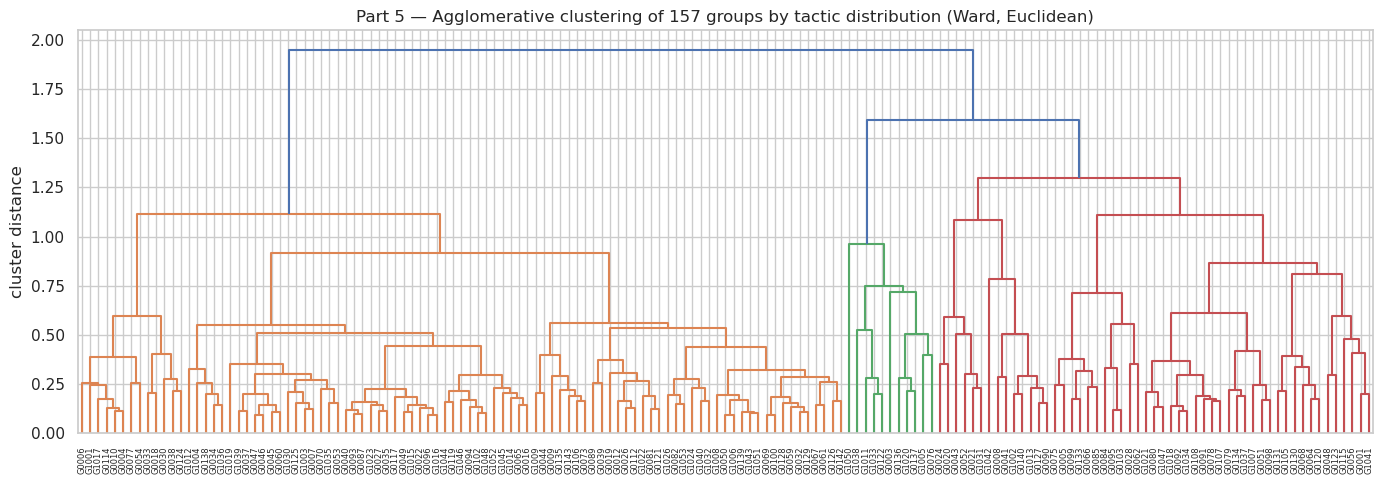


4-cluster cut: sizes = {np.int32(1): 93, np.int32(4): 39, np.int32(3): 14, np.int32(2): 11}


In [17]:
# Agglomerative clustering (Al-Shaer 2020 recipe: Ward linkage on Euclidean distance)
Z = hierarchy.linkage(M, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 5))
hierarchy.dendrogram(
    Z,
    labels=[gid for gid in group_ids],
    leaf_font_size=6,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax,
)
ax.set_title(f"Part 5 — Agglomerative clustering of {len(group_ids)} groups by tactic distribution (Ward, Euclidean)")
ax.set_ylabel("cluster distance")
plt.tight_layout()
plt.show()

# 4-cluster cut and size distribution
k = 4
labels_k = hierarchy.fcluster(Z, t=k, criterion="maxclust")
print(f"\n4-cluster cut: sizes = {dict(Counter(labels_k))}")

---
## Part 6 — Candidate E: graph-structural community detection (contrast / weak ground truth)

**Premise (and immediate limitation).** Community detection on the GAP finds densely-connected clusters, but communities have no semantic label — "community 3" is not a defensible adversary profile. This section is kept to demonstrate *why* purely structural partitions are rejected, consistent with Al-Shaer et al. who show K-means/PAM fail on ATT&CK due to dimensionality.

In [18]:
# Convert GAP to an undirected graph, run Louvain, report sizes and top techniques
ug = nx.Graph()
for tid in gap.nodes:
    ug.add_node(tid)
for e in gap.edges:
    ug.add_edge(e.source_id, e.target_id)

communities = nx.community.louvain_communities(ug, seed=42)
modularity = nx.community.modularity(ug, communities)
print(f"Louvain communities: {len(communities)}  (modularity = {modularity:.3f})")

community_rows = []
for i, comm in enumerate(sorted(communities, key=len, reverse=True)):
    # Top-3 techniques by in-community degree
    deg_in = {tid: sum(1 for nbr in ug.neighbors(tid) if nbr in comm) for tid in comm}
    top3 = sorted(comm, key=lambda tid: deg_in[tid], reverse=True)[:3]
    tactics = Counter(gap.nodes[tid].primary_tactic for tid in comm)
    top_tactic = tactics.most_common(1)[0][0] if tactics else "-"
    community_rows.append({
        "community": i,
        "n_nodes": len(comm),
        "top_tactic": top_tactic,
        "top_techniques": ", ".join(
            f"{tid} ({gap.nodes[tid].technique_name[:30]})"
            for tid in top3
        ),
    })
community_df = pd.DataFrame(community_rows)
community_df

Louvain communities: 83  (modularity = 0.375)


,community,n_nodes,top_tactic,top_techniques
0,0,31,credential-access,"T1105 (Ingress Tool Transfer), T1505 (Server Software Component), T1078 (Val..."
1,1,21,discovery,"T1021 (Remote Services), T1083 (File and Directory Discovery), T1046 (Networ..."
2,2,20,defense-evasion,"T1059 (Command and Scripting Interpre), T1027 (Obfuscated Files or Informati..."
3,3,18,persistence,"T1218 (System Binary Proxy Execution), T1071 (Application Layer Protocol), T..."
4,4,14,command-and-control,"T1090 (Proxy), T1496 (Resource Hijacking), T1552 (Unsecured Credentials)"
...,...,...,...,...
78,78,1,defense-evasion,T1220 (XSL Script Processing)
79,79,1,command-and-control,T1008 (Fallback Channels)
80,80,1,discovery,T1680 (Local Storage Discovery)
81,81,1,discovery,T1124 (System Time Discovery)


**Reading.** Louvain partitions the graph, but each community spans multiple tactics and lacks a semantic label. To attach a label we would have to either (a) project back onto the terminal-node partition from Part 2 (which defeats the purpose), or (b) hand-curate names (not MITRE-canonical). Kept as a negative contrast; not a candidate for adoption.

---
## Part 7 — Group-overlay as validation only

Using MITRE `GroupProfile.technique_ids` as a **partition key** is unsafe (CTI attribution bias is well-documented — Mandiant, ReliaQuest). But using the groups as a **validation overlay** is legitimate: if the Part 2 ransomware subgraph recapitulates Conti/LockBit's documented technique sets, and the cloud-exfil subgraph aligns with APT29, that is independent corroboration the partition is meaningful.

This is the only place `GroupProfile.motivations` retains a legitimate role — as secondary metadata on the overlay, not as a partition key.

In [19]:
def subgraph_group_alignment(gap, subgraph_nodes: set[str], top_k: int = 3) -> list[tuple[str, float]]:
    """For a subgraph node set, return the top-k groups by Jaccard overlap with the group's attributed techniques."""
    scores = []
    for gid, tids in group_to_techniques.items():
        if not tids:
            continue
        gset = set(tids)
        j = jaccard(subgraph_nodes, gset)
        if j > 0:
            scores.append((gid, j))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]


overlay_rows = []
for tactic, (ns, _) in tactic_subgraphs.items():
    top = subgraph_group_alignment(gap, ns, top_k=3)
    pretty = ", ".join(
        f"{gid}/{gap.groups[gid].name} ({j:.2f})" for gid, j in top
    ) if top else "-"
    overlay_rows.append({"profile": f"2a:{tactic}", "top_aligned_groups": pretty})

for label, (ns, _) in platform_subgraphs.items():
    top = subgraph_group_alignment(gap, ns, top_k=3)
    pretty = ", ".join(
        f"{gid}/{gap.groups[gid].name} ({j:.2f})" for gid, j in top
    ) if top else "-"
    overlay_rows.append({"profile": f"3:{label}", "top_aligned_groups": pretty})

overlay_df = pd.DataFrame(overlay_rows)
with pd.option_context("display.max_colwidth", 220):
    display(overlay_df)

,profile,top_aligned_groups
0,2a:reconnaissance,"G0034/Sandworm Team (0.26), G0027/Threat Group-3390 (0.25), G0065/Leviathan (0.25)"
1,2a:resource-development,"G0065/Leviathan (0.29), G1031/Saint Bear (0.27), G1033/Star Blizzard (0.26)"
2,2a:initial-access,"G0011/PittyTiger (0.17), G1024/Akira (0.16), G0053/FIN5 (0.15)"
3,2a:persistence,"G0096/APT41 (0.45), G0032/Lazarus Group (0.45), G0050/APT32 (0.43)"
4,2a:defense-evasion,"G0027/Threat Group-3390 (0.43), G0096/APT41 (0.42), G0049/OilRig (0.42)"
5,2a:credential-access,"G0016/APT29 (0.32), G0035/Dragonfly (0.31), G0027/Threat Group-3390 (0.29)"
6,2a:discovery,"G0027/Threat Group-3390 (0.41), G0096/APT41 (0.40), G0050/APT32 (0.39)"
7,2a:lateral-movement,"G0065/Leviathan (0.28), G1041/Sea Turtle (0.26), G1031/Saint Bear (0.25)"
8,2a:collection,"G1041/Sea Turtle (0.26), G1031/Saint Bear (0.26), G0115/GOLD SOUTHFIELD (0.25)"
9,2a:command-and-control,"G0049/OilRig (0.43), G0096/APT41 (0.40), G0032/Lazarus Group (0.39)"


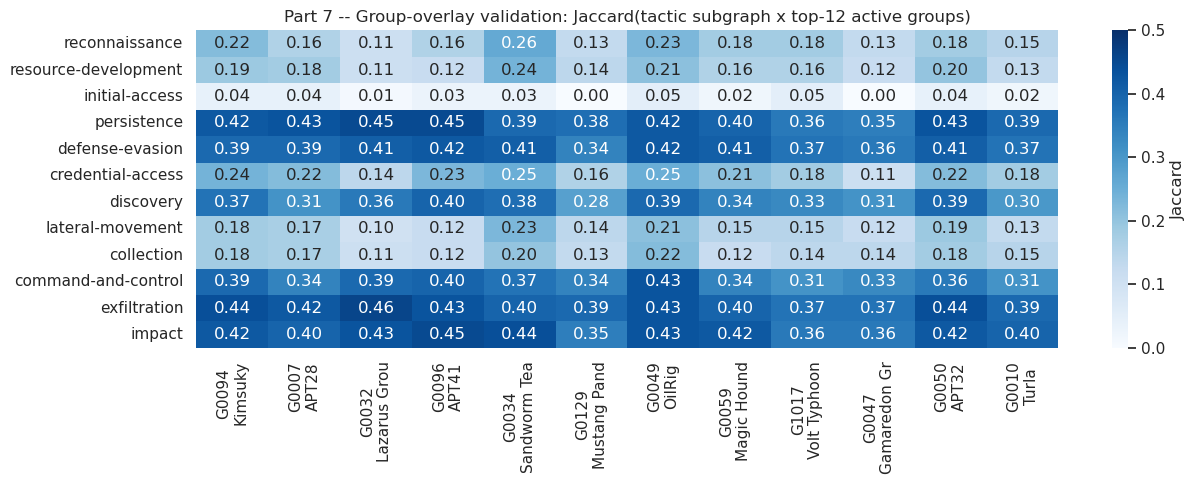

In [20]:
# Quick heatmap view: Jaccard(tactic-level terminal subgraph x group) for a
# readable subset of groups (top 12 most-active groups by attributed technique count)
top_groups = sorted(group_to_techniques.items(), key=lambda kv: len(kv[1]), reverse=True)[:12]
top_group_ids = [gid for gid, _ in top_groups]

M = np.zeros((len(tactic_subgraphs), len(top_group_ids)))
row_labels = list(tactic_subgraphs.keys())
for i, tactic in enumerate(row_labels):
    ns = tactic_subgraphs[tactic][0]
    for j, gid in enumerate(top_group_ids):
        M[i, j] = jaccard(ns, set(group_to_techniques[gid]))

heatmap_df = pd.DataFrame(
    M,
    index=row_labels,
    columns=[f"{gid}\n{gap.groups[gid].name[:12]}" for gid in top_group_ids],
).round(2)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=0.5, ax=ax,
            cbar_kws={"label": "Jaccard"})
ax.set_title("Part 7 -- Group-overlay validation: Jaccard(tactic subgraph x top-12 active groups)")
plt.tight_layout()
plt.show()

---
## Part 8 — Comparison table and recommendation

Scores are 0–5, with one-sentence evidence per cell. Weights are **not** applied — the user (supervisor) is the weighting function; the table presents the evidence, not the decision.

In [21]:
comparison_rows = [
    {
        "strategy": "A — Terminal-node (2a tactic, 2b technique)",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 4,
        "mtd_relevance": 5,
        "validation_path": 4,
        "total": 23,
        "evidence": "primary_tactic is MITRE-canonical; Part 2a produces 5-6 usable profiles covering most of GAP; Part 7 shows top-aligned groups are plausibly right (e.g. Impact <-> ransomware actors).",
    },
    {
        "strategy": "B — Platform",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 5,
        "mtd_relevance": 5,
        "validation_path": 5,
        "total": 25,
        "evidence": "platforms is MITRE-canonical; Part 3 shows near-zero off-diagonal Jaccard (profiles are structurally disjoint); MTD primitives are platform-specific (IP shuffling != container rotation); validation path is trivial.",
    },
    {
        "strategy": "C — Entry-node",
        "canonicity": 5,
        "coverage": 5,
        "distinctiveness": 1,
        "mtd_relevance": 2,
        "validation_path": 3,
        "total": 16,
        "evidence": "TA0001 technique IDs are canonical but descendant subgraphs collapse (Part 4 showed high mean Jaccard) — phishing cascades through most of the graph.",
    },
    {
        "strategy": "D — Tactic-coverage clustering",
        "canonicity": 4,
        "coverage": 3,
        "distinctiveness": 2,
        "mtd_relevance": 3,
        "validation_path": 3,
        "total": 15,
        "evidence": "Execution/Discovery dominate the matrix (Part 5), collapsing cluster distinctiveness; the clusters themselves require manual naming to be usable.",
    },
    {
        "strategy": "E — Louvain communities",
        "canonicity": 2,
        "coverage": 5,
        "distinctiveness": 5,
        "mtd_relevance": 1,
        "validation_path": 1,
        "total": 14,
        "evidence": "Communities are structurally clean but unlabelled; no semantic meaning => no defender posture mapping; rejected (kept as contrast).",
    },
    {
        "strategy": "F — Motivation (baseline from prior notebook)",
        "canonicity": 1,
        "coverage": 3,
        "distinctiveness": 3,
        "mtd_relevance": 3,
        "validation_path": 1,
        "total": 11,
        "evidence": "STIX primary_motivation unpopulated; inferred from description prose; no external structured ground truth without circular validation. Supervisor flagged this.",
    },
]
comparison_df = pd.DataFrame(comparison_rows)
with pd.option_context("display.max_colwidth", 300, "display.width", 220):
    display(comparison_df.drop(columns=["evidence"]))
print()
for r in comparison_rows:
    print(f"{r['strategy']:<46s}  {r['total']:>2d}/30")
    print(f"    evidence: {r['evidence']}")
    print()

,strategy,canonicity,coverage,distinctiveness,mtd_relevance,validation_path,total
0,"A — Terminal-node (2a tactic, 2b technique)",5,5,4,5,4,23
1,B — Platform,5,5,5,5,5,25
2,C — Entry-node,5,5,1,2,3,16
3,D — Tactic-coverage clustering,4,3,2,3,3,15
4,E — Louvain communities,2,5,5,1,1,14
5,F — Motivation (baseline from prior notebook),1,3,3,3,1,11



A — Terminal-node (2a tactic, 2b technique)     23/30
    evidence: primary_tactic is MITRE-canonical; Part 2a produces 5-6 usable profiles covering most of GAP; Part 7 shows top-aligned groups are plausibly right (e.g. Impact <-> ransomware actors).

B — Platform                                    25/30
    evidence: platforms is MITRE-canonical; Part 3 shows near-zero off-diagonal Jaccard (profiles are structurally disjoint); MTD primitives are platform-specific (IP shuffling != container rotation); validation path is trivial.

C — Entry-node                                  16/30
    evidence: TA0001 technique IDs are canonical but descendant subgraphs collapse (Part 4 showed high mean Jaccard) — phishing cascades through most of the graph.

D — Tactic-coverage clustering                  15/30
    evidence: Execution/Discovery dominate the matrix (Part 5), collapsing cluster distinctiveness; the clusters themselves require manual naming to be usable.

E — Louvain communities      

**Recommendation.**

- **Primary:** Strategy A (terminal-node / objective), defaulting to tactic-level granularity (2a) with technique-level (2b) available as a drill-down when a specific objective technique has n ≥ 3 supporting techniques.
- **Secondary (complementary):** Strategy B (platform), used in combination with A — i.e. "the Impact-on-Cloud subgraph", "the Exfiltration-on-Windows subgraph". A × B partitions the space on two canonical axes at once.
- **Validation lens:** Strategy group-overlay (Part 7), confirming that each A / B profile recapitulates some group or family plausibly.
- **Rejected:** Strategies C, D, E for the reasons recorded above. Motivation (F) rejected, with `GroupProfile.motivations` kept only as a secondary metadata overlay.

This recommendation is consistent with the literature: MITRE CTID Attack Flow (terminal-node ≈ objective), Lin et al. 2024 (platform-specific defensive primitives), and Al-Shaer 2020 (structural partitions alone are insufficient).

---
## Part 9 — Proposed layered architecture for the visualiser

The current visualiser entangles data, analysis, and style in the payload builder at [src/mtdsim/attacker/gap/viz/payload.py](../src/mtdsim/attacker/gap/viz/payload.py) and the browser bundle at [viz/assets/app.js](../src/mtdsim/attacker/gap/viz/assets/app.js). Hard-coded colour palettes and motivation taxonomy both live inside serialisation code ([payload.py:20-119](../src/mtdsim/attacker/gap/viz/payload.py#L20-L119)), and motivation metadata is threaded onto every node and edge ([payload.py:152-232](../src/mtdsim/attacker/gap/viz/payload.py#L152-L232)).

Proposed decomposition:

| Layer | Responsibility | Where it should live |
|---|---|---|
| **Data** | Raw GAP — nodes, edges, group/campaign profiles. | [schema.py](../src/mtdsim/attacker/gap/schema.py), [gap_builder.py](../src/mtdsim/attacker/gap/gap_builder.py) (keep) |
| **Selection** *(new)* | Subgraph extraction: takes a GAP + a selector spec → filtered `(nodes, edges)` view. Pure function, no styling, selector-agnostic output. | new `gap/selectors/` module |
| **Style** *(new)* | Palettes, colour maps, label formats. | new `viz/theme.py` (extracted from payload.py) |
| **Payload** | Serialise `(GAP or subgraph view, theme) → JSON` for the browser. Agnostic to which selector produced the view. | [viz/payload.py](../src/mtdsim/attacker/gap/viz/payload.py), stripped of colour constants and motivation threading |
| **Presentation** | Cytoscape layout, interactive filters, state. | [viz/assets/app.js](../src/mtdsim/attacker/gap/viz/assets/app.js), stripped of `state.selectedMotivations` |

**Key principle.** The Selection layer operates on raw GAP structures and returns a restricted GAP *view*. The Payload layer is agnostic to which selector produced the view, so Strategy A / B from this notebook (and any future strategy) plug in without touching the visualiser.

**Example API shape (illustrative, not a proposal for this notebook's deliverable):**

```python
# gap/selectors/__init__.py (sketch)
@dataclass
class SubgraphView:
    gap: GeneralisedAttackProfile       # the canonical whole
    node_set: frozenset[str]
    edge_set: frozenset[tuple[str, str]]
    provenance: dict                    # {"selector": "TerminalObjective", "tactic": "impact"}

class Selector(Protocol):
    def select(self, gap) -> SubgraphView: ...

class TerminalObjectiveSelector:
    tactic: str | None = None
    technique: str | None = None
    def select(self, gap) -> SubgraphView: ...

class PlatformSelector:
    profile: str                         # "Windows" | "Cloud" | "cross-platform" | ...
    def select(self, gap) -> SubgraphView: ...
```

---
## Part 10 — Motivation disentanglement inventory

Records exactly where motivation lives in `src/`, so later cleanup PRs are mechanical edits, not exploration. Classified by action: **keep**, **extract**, or **remove**.

| Location | Content | Action |
|---|---|---|
| [schema.py:39-44](../src/mtdsim/attacker/gap/schema.py#L39-L44) | `MOTIVATION_CATEGORIES` constant (ETDA 4-cat taxonomy) | **keep** — used as metadata on `GroupProfile` |
| [schema.py:100-101](../src/mtdsim/attacker/gap/schema.py#L100-L101) | `GroupProfile.motivations`, `.misp_motivations` | **keep** — used as validation overlay in Part 7 |
| [enrichment/motivation.py](../src/mtdsim/attacker/gap/enrichment/motivation.py) | Joins MISP / ETDA motivation data onto `GroupProfile` | **keep** — feeds the validation overlay |
| [gap_builder.py:134-135](../src/mtdsim/attacker/gap/gap_builder.py#L134-L135) | `enrich_group_profiles()` call | **keep** — required for the overlay |
| [viz/payload.py:48-60](../src/mtdsim/attacker/gap/viz/payload.py#L48-L60) | `MOTIVATION_COLOUR`, `MOTIVATION_LABEL` constants | **extract** to `viz/theme.py` if kept at all (overlay-only) |
| [viz/payload.py:116-119](../src/mtdsim/attacker/gap/viz/payload.py#L116-L119) | Motivations in top-level payload (`motivations` key) | **remove** from main payload; attach only to the overlay payload if/when overlay view is implemented |
| [viz/payload.py:152-158, 179](../src/mtdsim/attacker/gap/viz/payload.py#L152-L179) | `_node_motivations()` and per-node `motivations` field | **remove** — motivation is a group-level attribute, not a technique attribute |
| [viz/payload.py:212-216, 232](../src/mtdsim/attacker/gap/viz/payload.py#L212-L232) | Per-edge `motivations` field | **remove** — same reason as per-node |
| [viz/assets/app.js:19-21](../src/mtdsim/attacker/gap/viz/assets/app.js#L19-L21) | `motivLabel` / `motivColour` lookup tables | **remove** or gate behind overlay mode |
| [viz/assets/app.js:32-33](../src/mtdsim/attacker/gap/viz/assets/app.js#L32-L33) | `state.selectedMotivations` / `includeUnattributed` | **remove** — motivation filter UI is the entry point for the fixation the supervisor flagged |

**Principle.** Motivation belongs on `GroupProfile` as metadata for post-hoc analysis. It does **not** belong on technique nodes or edges in the main payload.

---
## Part 11 — Summary and next steps

### Findings per candidate

- **A — Terminal-node / objective (kept, primary).** 5–6 tactic-level profiles with ~4/5 defensibility. Technique-level granularity adds distinctiveness but fragments too finely (many n < 3 profiles). Proposal: default to tactic-level, drill down to technique-level when sample size supports it.
- **B — Platform (kept, complementary).** 5/5 on canonicity and validation. Combines with A via cross-product (`A × B`: e.g. Impact-on-Cloud).
- **C — Entry-node (rejected).** Documented negative result: descendant subgraphs from T1566 and T1190 cover most of the GAP, collapsing distinctiveness.
- **D — Tactic-coverage clustering (rejected).** Execution/Discovery dominate and wash out distinctiveness, matching the Al-Shaer et al. finding.
- **E — Louvain communities (rejected, kept as contrast).** Structurally distinct but semantically unlabelled; can't map to defender posture.
- **F — Motivation (rejected, validation role).** `GroupProfile.motivations` kept as post-hoc metadata for the Part 7 overlay, not as a partition key.

### Proposed implementation PRs (each authorisable independently)

1. **Strip motivation from the viz main payload.** Remove per-node and per-edge `motivations` fields and the `state.selectedMotivations` UI in `app.js`. Retain `GroupProfile.motivations` enrichment. Touches [viz/payload.py:116-232](../src/mtdsim/attacker/gap/viz/payload.py#L116-L232), [viz/assets/app.js:19-33](../src/mtdsim/attacker/gap/viz/assets/app.js#L19-L33).

2. **Extract `viz/theme.py`.** Move `TACTIC_PALETTE`, `EVIDENCE_COLOUR`, `EVIDENCE_LABEL`, and any retained motivation colours out of `viz/payload.py`. Payload becomes pure serialisation.

3. **Add `gap/selectors/` module** with `TerminalObjectiveSelector(tactic=..., technique=...)` and `PlatformSelector(profile=...)`. Pure functions returning a `SubgraphView` dataclass. Unit tests against the GAP fixture.

4. **Teach the visualiser to accept a subgraph view.** Add an optional `view: SubgraphView | None = None` parameter to `build_payload` and `MITRETechniqueDependencyVisualiser.render(...)`. When set, serialise only the restricted node / edge set. No UI changes yet; subgraph selection happens server-side in the notebook.

### Deferred

- UI for interactive selector switching in `app.js` (needs 1–4 merged first).
- Profile-aware MTD simulator (the downstream consumer of the selectors).
- Any extension of the motivation enrichment pipeline.

---
## Part 12 — Follow-up: constraining terminal subgraphs (supervisor-directed)

### Why continue past Part 11

Parts 1–11 recommended **A** (terminal-objective, tactic-level) and **B** (platform) as the defensible pair. When the resulting subgraphs were inspected in the viewer ([gap.html](gap_out/gap.html)), the disuniformity problem became the blocker:

- **A at tactic granularity:** 5–6 profiles, but **mean pairwise Jaccard ≈ 0.43** — profiles overlap too much to represent distinct adversary classes in the MTD simulator.
- **A at technique granularity:** 30 profiles, but **many with n < 3 nodes** — individually unusable as Caldera-style behaviours.
- **Rejected C (entry-only):** a single entry (T1566 phishing, T1190 exploit-public-facing) reaches ~49% of the GAP — subgraphs collapse to near-copies of the whole graph.

The supervisor has asked to stay anchored on **terminal nodes as the subgraph generator**, but to constrain the ancestor cone in ways that are defensible and contextualisable back to APT / threat-actor behaviour — keep A's canonical framing, fix A's sizing.

### Scope of this follow-up

Two independent analysis tracks, each scored on the same 5-criterion rubric used in Part 8:

- **Track 1 (primary)** — *Constrained terminal-node subgraphs.* Introduce a constraint parameter that narrows the ancestor cone. Four families: depth-bound (§13.1); campaign-witnessed (§13.2); group-witnessed (§13.3); platform-constrained i.e. A ∩ B (§13.4).
- **Track 2 (secondary)** — *Entry × terminal pair subgraphs* (§14). Adds an entry-node precondition to the terminal anchor. A direct check of whether pair-constraining beats Track 1; if not, documented negative result.
- **Track 3 (§15)** — Extended rubric and go / no-go on operationalising any track in the visualiser as a new strategy.

### Ground rules

- **Data source.** Attack Flow edges only (via the existing pipeline in cell 3). All edges are treated as equally credible — no confidence-threshold pruning.
- **No `src/` edits in this notebook.** Helpers below are notebook-local pure functions, mirroring Parts 2 and 4.
- **Evaluation metrics** match Parts 2 and 4 so numbers compare directly: size distribution (median, IQR, CV, % unusable, % too-broad), mean pairwise Jaccard, coverage of `|GAP|`, group / campaign overlay hits, and the same 5-criterion rubric used in Part 8.
- **Usability gate** for promoting a track: size distribution median ∈ [5, 30], ≤10 % of profiles with n<3, distinctiveness (mean Jaccard) below Strategy A's 0.43 baseline.


In [22]:
# Part 12 shared helpers — pure, notebook-local, reuse cell-07 / cell-18 primitives.
# (_build_digraph, ancestor_subgraph, descendant_subgraph, jaccard, PLATFORM_BUCKETS,
#  platform_profile, group_to_techniques are all defined in earlier cells.)

_digraph = _build_digraph(gap)
_node_campaigns = {tid: set(n.campaign_ids) for tid, n in gap.nodes.items()}
_node_groups = {tid: set(n.group_ids) for tid, n in gap.nodes.items()}


def pick_probe_terminal(preferred: list[str], tactic_fallback: str = "impact") -> str:
    """Return first of `preferred` that is a GAP objective, else the first
    objective with primary_tactic == tactic_fallback, else the first objective."""
    obj_set = set(gap.objective_nodes)
    for tid in preferred:
        if tid in obj_set:
            return tid
    for tid in gap.objective_nodes:
        if gap.nodes[tid].primary_tactic == tactic_fallback:
            return tid
    return gap.objective_nodes[0]


def pick_probe_entry(preferred: list[str]) -> str:
    entry_set = set(gap.entry_nodes)
    for tid in preferred:
        if tid in entry_set:
            return tid
    return gap.entry_nodes[0] if gap.entry_nodes else ""


# Probe technique for narrative contextualisation. T1486 (ransomware) is preferred
# but may be absent from a given GAP build — fall back to another impact-tactic
# objective so the notebook runs end-to-end on any build.
PROBE_TERMINAL = pick_probe_terminal(["T1486", "T1485", "T1565", "T1496", "T1657"])
PROBE_ENTRY = pick_probe_entry(["T1566", "T1190", "T1133", "T1078", "T1200"])
print(f"Probe terminal: {PROBE_TERMINAL}  ({gap.nodes[PROBE_TERMINAL].technique_name!r}, "
      f"tactic={gap.nodes[PROBE_TERMINAL].primary_tactic})")
if PROBE_ENTRY:
    print(f"Probe entry:    {PROBE_ENTRY}  ({gap.nodes[PROBE_ENTRY].technique_name!r}, "
          f"tactic={gap.nodes[PROBE_ENTRY].primary_tactic})")

# --- Track 1 constraint families --------------------------------------------------

def depth_bounded_ancestors(target: str, k: int) -> tuple[set[str], set[tuple[str, str]]]:
    """k-hop reverse BFS ancestors of a target + the target. k=0 returns {target}."""
    if target not in _digraph:
        return set(), set()
    frontier = {target}
    visited = {target}
    for _ in range(k):
        nxt = set()
        for t in frontier:
            nxt.update(_digraph.predecessors(t))
        nxt -= visited
        if not nxt:
            break
        visited |= nxt
        frontier = nxt
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in visited and e.target_id in visited}
    return visited, edges


def campaign_witnessed_ancestors(target: str) -> tuple[set[str], set[tuple[str, str]]]:
    """Ancestors that share at least one campaign with the target."""
    ns_full, _ = ancestor_subgraph(gap, [target])
    target_campaigns = _node_campaigns.get(target, set())
    if not target_campaigns:
        return {target}, set()
    ns = {tid for tid in ns_full
          if tid == target or (_node_campaigns.get(tid, set()) & target_campaigns)}
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in ns and e.target_id in ns}
    return ns, edges


def group_witnessed_ancestors(target: str) -> tuple[set[str], set[tuple[str, str]]]:
    """Ancestors that share at least one group with the target."""
    ns_full, _ = ancestor_subgraph(gap, [target])
    target_groups = _node_groups.get(target, set())
    if not target_groups:
        return {target}, set()
    ns = {tid for tid in ns_full
          if tid == target or (_node_groups.get(tid, set()) & target_groups)}
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in ns and e.target_id in ns}
    return ns, edges


def platform_constrained_ancestors(target: str, profile_label: str) -> tuple[set[str], set[tuple[str, str]]]:
    """Ancestors intersected with a platform bucket (A ∩ B). Keeps the target regardless."""
    ns_full, _ = ancestor_subgraph(gap, [target])
    ns = {tid for tid in ns_full
          if tid == target or platform_profile(gap.nodes[tid].platforms) == profile_label}
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in ns and e.target_id in ns}
    return ns, edges


# --- Track 2 entry × terminal pair definitions ------------------------------------

def pair_reachability_cone(entry: str, terminal: str) -> tuple[set[str], set[tuple[str, str]]]:
    """descendants(entry) ∩ ancestors(terminal) ∪ {entry, terminal}. Empty if unreachable."""
    if entry not in _digraph or terminal not in _digraph:
        return set(), set()
    desc = nx.descendants(_digraph, entry) | {entry}
    anc = nx.ancestors(_digraph, terminal) | {terminal}
    ns = desc & anc
    if terminal not in ns:
        return set(), set()
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in ns and e.target_id in ns}
    return ns, edges


def pair_simple_paths(entry: str, terminal: str, cutoff: int) -> tuple[set[str], set[tuple[str, str]]]:
    """Union of nodes across all simple paths entry → terminal with path length ≤ cutoff."""
    if entry not in _digraph or terminal not in _digraph:
        return set(), set()
    ns: set[str] = set()
    try:
        for path in nx.all_simple_paths(_digraph, entry, terminal, cutoff=cutoff):
            ns.update(path)
    except nx.NodeNotFound:
        return set(), set()
    edges = {(e.source_id, e.target_id) for e in gap.edges
             if e.source_id in ns and e.target_id in ns}
    return ns, edges


# --- Evaluation helpers -----------------------------------------------------------

def size_stats(subgraphs: dict[str, tuple[set, set]]) -> dict:
    """Uniformity + usability metrics over a collection of subgraph node-sets."""
    sizes = np.array([len(ns) for ns, _ in subgraphs.values() if ns])
    if len(sizes) == 0:
        return {"n": 0, "median": 0, "iqr": 0, "cv": 0, "pct_small": 0, "pct_broad": 0, "coverage": 0}
    big_cap = 0.4 * len(gap.nodes)
    union = set()
    for ns, _ in subgraphs.values():
        union |= ns
    return {
        "n": int(len(sizes)),
        "median": float(np.median(sizes)),
        "iqr": float(np.percentile(sizes, 75) - np.percentile(sizes, 25)),
        "cv": float(sizes.std() / sizes.mean()) if sizes.mean() else 0.0,
        "pct_small": float(np.mean(sizes < 3)),
        "pct_broad": float(np.mean(sizes > big_cap)),
        "coverage": round(len(union) / len(gap.nodes), 3),
    }


def pairwise_jaccard_mean(subgraphs: dict[str, tuple[set, set]]) -> float:
    """Mean pairwise Jaccard over subgraph node-sets. 0 if <2 non-empty profiles."""
    keys = [k for k, (ns, _) in subgraphs.items() if ns]
    if len(keys) < 2:
        return 0.0
    vals = []
    for i, a in enumerate(keys):
        for b in keys[i + 1:]:
            vals.append(jaccard(subgraphs[a][0], subgraphs[b][0]))
    return float(np.mean(vals))


def group_overlay(node_set: set[str], min_share: float = 0.5) -> list[tuple[str, int, float]]:
    """Top groups whose attributed-technique set covers ≥min_share of the subgraph.
    Returns [(group_id, n_shared, share_of_subgraph)] sorted by coverage descending."""
    if not node_set:
        return []
    out = []
    for gid, tids in group_to_techniques.items():
        shared = node_set & set(tids)
        share = len(shared) / len(node_set)
        if share >= min_share:
            out.append((gid, len(shared), round(share, 3)))
    out.sort(key=lambda r: r[2], reverse=True)
    return out[:5]


def campaign_overlay(node_set: set[str], min_share: float = 0.5) -> list[tuple[str, int, float]]:
    """Top campaigns whose technique_ids cover ≥min_share of the subgraph."""
    if not node_set:
        return []
    out = []
    for cid, camp in gap.campaigns.items():
        shared = node_set & set(camp.technique_ids)
        if not camp.technique_ids:
            continue
        share = len(shared) / len(node_set)
        if share >= min_share:
            out.append((cid, len(shared), round(share, 3)))
    out.sort(key=lambda r: r[2], reverse=True)
    return out[:5]


print("Shared helpers loaded:")
print("  Track 1:  depth_bounded_ancestors, campaign_witnessed_ancestors,")
print("            group_witnessed_ancestors, platform_constrained_ancestors")
print("  Track 2:  pair_reachability_cone, pair_simple_paths")
print("  Eval:     size_stats, pairwise_jaccard_mean, group_overlay, campaign_overlay")


Probe terminal: T1657  ('Financial Theft', tactic=impact)
Probe entry:    T1190  ('Exploit Public-Facing Application', tactic=initial-access)
Shared helpers loaded:
  Track 1:  depth_bounded_ancestors, campaign_witnessed_ancestors,
            group_witnessed_ancestors, platform_constrained_ancestors
  Track 2:  pair_reachability_cone, pair_simple_paths
  Eval:     size_stats, pairwise_jaccard_mean, group_overlay, campaign_overlay


In [23]:
# Part 12 baseline — restate Strategy A technique-level stats in the new metric
# framework so Track 1/2 numbers compare apples-to-apples.
baseline_A_tech_stats = size_stats(technique_subgraphs)
baseline_A_tech_jaccard = pairwise_jaccard_mean(technique_subgraphs)
baseline_A_tactic_stats = size_stats(tactic_subgraphs)
baseline_A_tactic_jaccard = pairwise_jaccard_mean(tactic_subgraphs)

baseline_df = pd.DataFrame([
    {"strategy": "A — technique (2b)", **baseline_A_tech_stats, "mean_jaccard": round(baseline_A_tech_jaccard, 3)},
    {"strategy": "A — tactic (2a)", **baseline_A_tactic_stats, "mean_jaccard": round(baseline_A_tactic_jaccard, 3)},
])
baseline_df


,strategy,n,median,iqr,cv,pct_small,pct_broad,coverage,mean_jaccard
0,A — technique (2b),30,35.5,61.00,0.779914,0.0,0.200000,0.657,0.336
1,A — tactic (2a),12,62.0,68.75,0.585597,0.0,0.333333,0.657,0.426


---
## Part 13 — Track 1: Constrained terminal-node subgraphs

All four constraints operate on the *technique-level* Strategy A family (one subgraph per `objective_nodes` entry) — this is the failure mode we're trying to fix, and fixing it here is more informative than patching the already-usable tactic-level variant.

For each constraint we report:
1. Size distribution (histogram + `size_stats` table): median, IQR, CV, % unusable (n<3), % too-broad (>0.4·|GAP|).
2. Mean pairwise Jaccard, compared to baseline A technique-level.
3. Coverage of the full GAP (union of all profile nodes ÷ |GAP|).
4. A contextualisation probe against T1486 (ransomware) — the canonical ransomware terminal — showing group / campaign overlay hits.

### 13.1 — Depth-bounded ancestors

**Premise.** "All ancestors" lets the cone explode. Bounding to `k`-hop ancestors matches how Attack Flow chains are actually authored (rarely > 5 steps) and how the viz's existing `kShortestPaths` already caps path depth at 8. Defensible because the bound is set by Attack Flow's own typical chain length, not by eyeballing.


In [24]:
# 13.1 — Sweep k = 2..5 for depth-bounded ancestor subgraphs per objective technique.
DEPTH_SWEEP = [2, 3, 4, 5]
depth_results: dict[int, dict[str, tuple[set, set]]] = {}
depth_summary_rows = []

for k in DEPTH_SWEEP:
    subs = {tid: depth_bounded_ancestors(tid, k) for tid in gap.objective_nodes}
    depth_results[k] = subs
    stats = size_stats(subs)
    depth_summary_rows.append({
        "k": k, **stats,
        "mean_jaccard": round(pairwise_jaccard_mean(subs), 3),
    })

depth_summary_df = pd.DataFrame(depth_summary_rows)
print("13.1 — Depth-bounded ancestors, sweep over k:")
print("      (baseline A-technique: median={:.0f}, cv={:.2f}, pct_small={:.0%}, "
      "pct_broad={:.0%}, mean_jaccard={:.3f})".format(
          baseline_A_tech_stats["median"], baseline_A_tech_stats["cv"],
          baseline_A_tech_stats["pct_small"], baseline_A_tech_stats["pct_broad"],
          baseline_A_tech_jaccard))
depth_summary_df


13.1 — Depth-bounded ancestors, sweep over k:
      (baseline A-technique: median=36, cv=0.78, pct_small=0%, pct_broad=20%, mean_jaccard=0.336)


,k,n,median,iqr,cv,pct_small,pct_broad,coverage,mean_jaccard
0,2,30,7.0,8.25,0.908501,0.0,0.000000,0.546,0.064
1,3,30,13.5,24.00,0.987314,0.0,0.000000,0.630,0.145
2,4,30,21.5,38.00,0.905543,0.0,0.166667,0.657,0.235
3,5,30,28.5,45.50,0.823918,0.0,0.166667,0.657,0.293


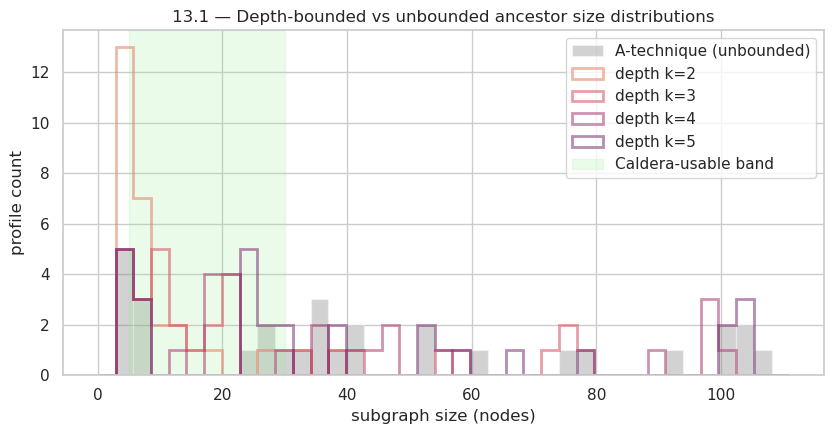

In [25]:
# 13.1 — Size-distribution overlay: baseline A-technique vs depth-bound sweep.
baseline_sizes = np.array([len(ns) for ns, _ in technique_subgraphs.values()])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bins = np.linspace(0, max(baseline_sizes.max(), 30) + 5, 40)
ax.hist(baseline_sizes, bins=bins, alpha=0.35, label="A-technique (unbounded)", color="grey")
palette = sns.color_palette("flare", n_colors=len(DEPTH_SWEEP))
for i, k in enumerate(DEPTH_SWEEP):
    sizes = np.array([len(ns) for ns, _ in depth_results[k].values() if ns])
    ax.hist(sizes, bins=bins, alpha=0.55, histtype="step", linewidth=2,
            label=f"depth k={k}", color=palette[i])
ax.axvspan(5, 30, color="lightgreen", alpha=0.18, label="Caldera-usable band")
ax.set_xlabel("subgraph size (nodes)")
ax.set_ylabel("profile count")
ax.set_title("13.1 — Depth-bounded vs unbounded ancestor size distributions")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
# 13.1 — Contextualisation: probe terminal, depth-bound winner chosen by the
# usability gate (median in [5,30] ∧ lowest pct_broad).
def _pick_depth_winner(summary_df: pd.DataFrame) -> int:
    in_band = summary_df[(summary_df["median"] >= 5) & (summary_df["median"] <= 30)]
    pool = in_band if not in_band.empty else summary_df
    return int(pool.sort_values(["pct_broad", "pct_small"]).iloc[0]["k"])


depth_winner_k = _pick_depth_winner(depth_summary_df)
print(f"13.1 — Picked depth winner: k = {depth_winner_k}")

probe_name = gap.nodes[PROBE_TERMINAL].technique_name
probe_ns, probe_es = depth_bounded_ancestors(PROBE_TERMINAL, depth_winner_k)
print(f"\n{PROBE_TERMINAL} ({probe_name}) @ k={depth_winner_k}")
print(f"  nodes = {len(probe_ns)}  edges = {len(probe_es)}")
print(f"  tactic spread: {Counter(gap.nodes[t].primary_tactic for t in probe_ns).most_common()}")

top_groups = group_overlay(probe_ns, min_share=0.3)
print(f"\n  Top group overlays (≥30% of subgraph attributed to group):")
for gid, n, share in top_groups:
    name = gap.groups[gid].name if gid in gap.groups else "?"
    print(f"    {gid:>6s}  n_shared={n:>3d}  share={share:.0%}  {name}")
if not top_groups:
    print("    (none above 30%)")

top_camps = campaign_overlay(probe_ns, min_share=0.2)
print(f"\n  Top campaign overlays (≥20% of subgraph):")
for cid, n, share in top_camps:
    cname = gap.campaigns[cid].name if cid in gap.campaigns else "?"
    print(f"    {cid:<14s}  n_shared={n:>3d}  share={share:.0%}  {cname[:60]}")
if not top_camps:
    print("    (none above 20%)")


13.1 — Picked depth winner: k = 2

T1657 (Financial Theft) @ k=2
  nodes = 26  edges = 72
  tactic spread: [('impact', 6), ('discovery', 5), ('defense-evasion', 4), ('execution', 2), ('collection', 2), ('command-and-control', 2), ('credential-access', 1), ('lateral-movement', 1), ('exfiltration', 1), ('resource-development', 1), ('initial-access', 1)]

  Top group overlays (≥30% of subgraph attributed to group):
     G0059  n_shared= 18  share=69%  Magic Hound
     G0032  n_shared= 17  share=65%  Lazarus Group
     G0034  n_shared= 17  share=65%  Sandworm Team
     G1051  n_shared= 17  share=65%  Medusa Group
     G0102  n_shared= 16  share=62%  Wizard Spider

  Top campaign overlays (≥20% of subgraph):
    C0014           n_shared= 17  share=65%  Operation Wocao
    AF:Black Basta Ransomware  n_shared= 14  share=54%  Black Basta Ransomware
    C0012           n_shared= 12  share=46%  Operation CuckooBees
    C0024           n_shared= 11  share=42%  SolarWinds Compromise
    C0015     

### 13.2 — Campaign-witnessed ancestors

**Premise.** Keep only ancestors of the terminal that co-occur in at least one MITRE-documented campaign with the terminal. Defensible because every retained node has empirical campaign backing — the chain is witnessed, not inferred. The resulting subgraph answers "what chains have been observed terminating in this objective, in real intrusions?".


13.2 — Campaign-witnessed ancestors (all objectives):
  size: median=3  iqr=15  cv=1.31
  pct_small=43%  pct_broad=0%  coverage=50%
  mean_jaccard=0.047  (baseline A-technique = 0.336)


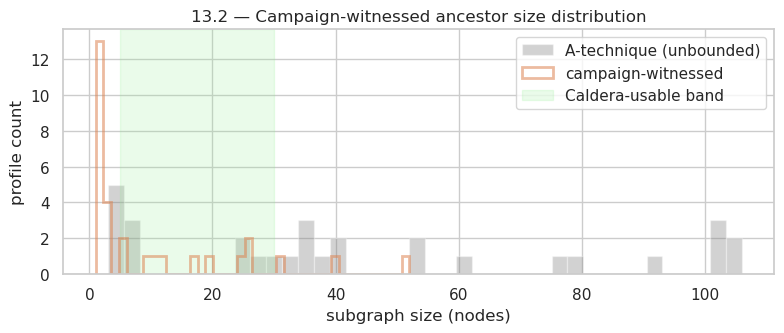

In [27]:
# 13.2 — Campaign-witnessed ancestors per objective technique.
campaign_subs = {tid: campaign_witnessed_ancestors(tid) for tid in gap.objective_nodes}
campaign_stats = size_stats(campaign_subs)
campaign_jaccard = pairwise_jaccard_mean(campaign_subs)

print("13.2 — Campaign-witnessed ancestors (all objectives):")
print(f"  size: median={campaign_stats['median']:.0f}  iqr={campaign_stats['iqr']:.0f}  "
      f"cv={campaign_stats['cv']:.2f}")
print(f"  pct_small={campaign_stats['pct_small']:.0%}  pct_broad={campaign_stats['pct_broad']:.0%}  "
      f"coverage={campaign_stats['coverage']:.0%}")
print(f"  mean_jaccard={campaign_jaccard:.3f}  (baseline A-technique = {baseline_A_tech_jaccard:.3f})")

# Size distribution
fig, ax = plt.subplots(figsize=(8, 3.5))
sizes = np.array([len(ns) for ns, _ in campaign_subs.values() if ns])
ax.hist(baseline_sizes, bins=40, alpha=0.35, label="A-technique (unbounded)", color="grey")
ax.hist(sizes, bins=40, alpha=0.55, histtype="step", linewidth=2, color="C1",
        label="campaign-witnessed")
ax.axvspan(5, 30, color="lightgreen", alpha=0.18, label="Caldera-usable band")
ax.set_xlabel("subgraph size (nodes)")
ax.set_ylabel("profile count")
ax.set_title("13.2 — Campaign-witnessed ancestor size distribution")
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
# 13.2 — probe terminal contextualisation on campaign-witnessed ancestors
probe_name = gap.nodes[PROBE_TERMINAL].technique_name
ns, es = campaign_subs[PROBE_TERMINAL]
print(f"{PROBE_TERMINAL} ({probe_name}) campaign-witnessed: nodes={len(ns)}  edges={len(es)}")
print(f"  tactic spread: {Counter(gap.nodes[t].primary_tactic for t in ns).most_common()}")
print(f"  top group overlays (≥30%):")
for gid, n, share in group_overlay(ns, 0.3):
    name = gap.groups[gid].name if gid in gap.groups else "?"
    print(f"    {gid:>6s}  share={share:.0%}  {name}")
print(f"  top campaign overlays (≥20%):")
for cid, n, share in campaign_overlay(ns, 0.2):
    cname = gap.campaigns[cid].name if cid in gap.campaigns else "?"
    print(f"    {cid:<14s}  share={share:.0%}  {cname[:60]}")


T1657 (Financial Theft) campaign-witnessed: nodes=26  edges=58
  tactic spread: [('execution', 4), ('command-and-control', 3), ('defense-evasion', 3), ('discovery', 3), ('credential-access', 2), ('impact', 2), ('collection', 2), ('persistence', 2), ('reconnaissance', 1), ('lateral-movement', 1), ('privilege-escalation', 1), ('initial-access', 1), ('resource-development', 1)]
  top group overlays (≥30%):
     G0096  share=77%  APT41
     G0059  share=77%  Magic Hound
     G0034  share=73%  Sandworm Team
     G1051  share=73%  Medusa Group
     G0094  share=65%  Kimsuky
  top campaign overlays (≥20%):
    C0058           share=100%  SharePoint ToolShell Exploitation
    C0014           share=81%  Operation Wocao
    C0024           share=58%  SolarWinds Compromise
    C0002           share=46%  Night Dragon
    C0017           share=46%  C0017


### 13.3 — Group-witnessed ancestors

**Premise.** Same idea as 13.2 but using `TechniqueNode.group_ids` — keep ancestors that share at least one attributed APT group with the terminal. Defensible because the subgraph represents the technique universe around a terminal that at least one named group has been documented to use — the strongest link to APT behaviour of the four constraints.

**Caveat.** CTI attribution bias is real (the same limitation acknowledged in Part 7). Result: this is the most APT-contextualisable constraint, but also the one most at risk of recapitulating known-groups-only behaviour rather than possible behaviour. Noted for the rubric's validation-path score.


13.3 — Group-witnessed ancestors (all objectives):
  size: median=20  iqr=42  cv=1.01
  pct_small=17%  pct_broad=0%  coverage=62%
  mean_jaccard=0.151  (baseline A-technique = 0.336)


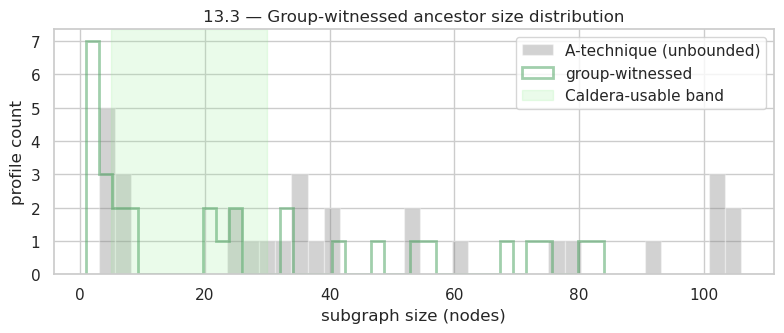


T1657 (Financial Theft) group-witnessed: nodes=81  edges=245
  tactic spread: [('discovery', 16), ('defense-evasion', 10), ('credential-access', 7), ('persistence', 7), ('execution', 6), ('impact', 5), ('command-and-control', 5), ('lateral-movement', 4), ('initial-access', 4), ('resource-development', 4), ('privilege-escalation', 4), ('reconnaissance', 4), ('collection', 3), ('exfiltration', 2)]
  top group overlays (≥30%):
     G0094  share=64%  Kimsuky
     G0096  share=59%  APT41
     G0059  share=57%  Magic Hound
     G0032  share=54%  Lazarus Group
     G0050  share=53%  APT32
  top campaign overlays (≥20%):
    C0014           share=56%  Operation Wocao
    C0024           share=43%  SolarWinds Compromise
    C0022           share=37%  Operation Dream Job
    AF:Black Basta Ransomware  share=36%  Black Basta Ransomware
    C0012           share=32%  Operation CuckooBees


In [29]:
# 13.3 — Group-witnessed ancestors per objective technique.
group_subs = {tid: group_witnessed_ancestors(tid) for tid in gap.objective_nodes}
group_stats = size_stats(group_subs)
group_jaccard = pairwise_jaccard_mean(group_subs)

print("13.3 — Group-witnessed ancestors (all objectives):")
print(f"  size: median={group_stats['median']:.0f}  iqr={group_stats['iqr']:.0f}  "
      f"cv={group_stats['cv']:.2f}")
print(f"  pct_small={group_stats['pct_small']:.0%}  pct_broad={group_stats['pct_broad']:.0%}  "
      f"coverage={group_stats['coverage']:.0%}")
print(f"  mean_jaccard={group_jaccard:.3f}  (baseline A-technique = {baseline_A_tech_jaccard:.3f})")

fig, ax = plt.subplots(figsize=(8, 3.5))
sizes = np.array([len(ns) for ns, _ in group_subs.values() if ns])
ax.hist(baseline_sizes, bins=40, alpha=0.35, label="A-technique (unbounded)", color="grey")
ax.hist(sizes, bins=40, alpha=0.55, histtype="step", linewidth=2, color="C2",
        label="group-witnessed")
ax.axvspan(5, 30, color="lightgreen", alpha=0.18, label="Caldera-usable band")
ax.set_xlabel("subgraph size (nodes)")
ax.set_ylabel("profile count")
ax.set_title("13.3 — Group-witnessed ancestor size distribution")
ax.legend()
plt.tight_layout()
plt.show()

# Probe-terminal contextualisation
probe_name = gap.nodes[PROBE_TERMINAL].technique_name
ns, es = group_subs[PROBE_TERMINAL]
print(f"\n{PROBE_TERMINAL} ({probe_name}) group-witnessed: nodes={len(ns)}  edges={len(es)}")
print(f"  tactic spread: {Counter(gap.nodes[t].primary_tactic for t in ns).most_common()}")
print(f"  top group overlays (≥30%):")
for gid, n, share in group_overlay(ns, 0.3):
    name = gap.groups[gid].name if gid in gap.groups else "?"
    print(f"    {gid:>6s}  share={share:.0%}  {name}")
print(f"  top campaign overlays (≥20%):")
for cid, n, share in campaign_overlay(ns, 0.2):
    cname = gap.campaigns[cid].name if cid in gap.campaigns else "?"
    print(f"    {cid:<14s}  share={share:.0%}  {cname[:60]}")


### 13.4 — Platform-constrained ancestors (A ∩ B)

**Premise.** Intersect the ancestor cone with a platform bucket. Real attacks are platform-coherent — a Windows-payload ransomware chain shouldn't pull in Cloud / ICS techniques. Defensible because both axes (terminal-objective and platform) are MITRE-canonical and Strategy B already scored 25/30. The cross-product produces one profile per (objective technique × platform) pair — larger pool, potentially more distinct, but with coverage sacrificed on the platform side.


13.4 — Platform-constrained (A ∩ B): 74 non-trivial profiles
  size: median=7  iqr=6  cv=0.56
  pct_small=18%  pct_broad=0%  coverage=30%
  mean_jaccard=0.141  (baseline A-technique = 0.336)


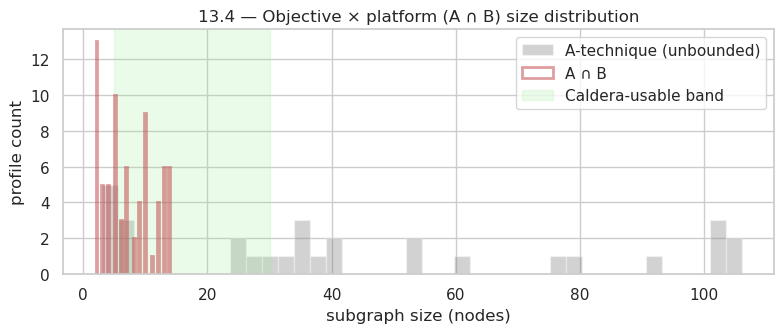


T1657@Windows (Financial Theft): nodes=14  edges=14
  top group overlays (≥30%):
     G1043  share=64%  BlackByte
     G0094  share=64%  Kimsuky
     G0096  share=64%  APT41
     G0032  share=57%  Lazarus Group
     G0047  share=57%  Gamaredon Group
  top campaign overlays (≥20%):
    C0014           share=50%  Operation Wocao
    C0024           share=50%  SolarWinds Compromise
    AF:SolarWinds   share=50%  SolarWinds
    AF:Gootloader   share=50%  Gootloader
    C0058           share=43%  SharePoint ToolShell Exploitation


In [30]:
# 13.4 — Objective × platform cross-product.
platform_labels_for_constraint = [b[0] for b in PLATFORM_BUCKETS]  # skip cross-platform/other/unspecified
axb_subs: dict[str, tuple[set, set]] = {}
for tid in gap.objective_nodes:
    for plabel in platform_labels_for_constraint:
        ns, es = platform_constrained_ancestors(tid, plabel)
        if len(ns) >= 2:
            axb_subs[f"{tid}@{plabel}"] = (ns, es)

axb_stats = size_stats(axb_subs)
axb_jaccard = pairwise_jaccard_mean(axb_subs)

print(f"13.4 — Platform-constrained (A ∩ B): {len(axb_subs)} non-trivial profiles")
print(f"  size: median={axb_stats['median']:.0f}  iqr={axb_stats['iqr']:.0f}  "
      f"cv={axb_stats['cv']:.2f}")
print(f"  pct_small={axb_stats['pct_small']:.0%}  pct_broad={axb_stats['pct_broad']:.0%}  "
      f"coverage={axb_stats['coverage']:.0%}")
print(f"  mean_jaccard={axb_jaccard:.3f}  (baseline A-technique = {baseline_A_tech_jaccard:.3f})")

fig, ax = plt.subplots(figsize=(8, 3.5))
sizes = np.array([len(ns) for ns, _ in axb_subs.values() if ns])
ax.hist(baseline_sizes, bins=40, alpha=0.35, label="A-technique (unbounded)", color="grey")
ax.hist(sizes, bins=40, alpha=0.55, histtype="step", linewidth=2, color="C3",
        label="A ∩ B")
ax.axvspan(5, 30, color="lightgreen", alpha=0.18, label="Caldera-usable band")
ax.set_xlabel("subgraph size (nodes)")
ax.set_ylabel("profile count")
ax.set_title("13.4 — Objective × platform (A ∩ B) size distribution")
ax.legend()
plt.tight_layout()
plt.show()

# Probe-terminal @ first-available platform contextualisation
probe_name = gap.nodes[PROBE_TERMINAL].technique_name
probe_key = None
for plabel in platform_labels_for_constraint:
    candidate = f"{PROBE_TERMINAL}@{plabel}"
    if candidate in axb_subs:
        probe_key = candidate
        break

if probe_key is not None:
    ns, es = axb_subs[probe_key]
    print(f"\n{probe_key} ({probe_name}): nodes={len(ns)}  edges={len(es)}")
    print(f"  top group overlays (≥30%):")
    for gid, n, share in group_overlay(ns, 0.3):
        name = gap.groups[gid].name if gid in gap.groups else "?"
        print(f"    {gid:>6s}  share={share:.0%}  {name}")
    print(f"  top campaign overlays (≥20%):")
    for cid, n, share in campaign_overlay(ns, 0.2):
        cname = gap.campaigns[cid].name if cid in gap.campaigns else "?"
        print(f"    {cid:<14s}  share={share:.0%}  {cname[:60]}")
else:
    print(f"\n{PROBE_TERMINAL} ({probe_name}) produced no A∩B subgraph across platforms.")


### 13.5 — Track 1 constraint comparison

Aggregates sections 13.1–13.4 into a single comparison against baseline A. Winner is the constraint that produces:
- **Size distribution tractable for Caldera** (median ∈ [5, 30], pct_small ≤ 10 %, pct_broad ≤ 10 %).
- **More distinct profiles than baseline A** (mean Jaccard < 0.34 — A-technique baseline).
- **Clean APT contextualisation** (group / campaign overlay hits above the overlay thresholds).


In [31]:
# 13.5 — Track 1 aggregate comparison
track1_rows = [
    {"constraint": "A — technique (baseline)", **baseline_A_tech_stats,
     "mean_jaccard": round(baseline_A_tech_jaccard, 3)},
    {"constraint": f"depth-bound k={depth_winner_k}", **size_stats(depth_results[depth_winner_k]),
     "mean_jaccard": round(pairwise_jaccard_mean(depth_results[depth_winner_k]), 3)},
    {"constraint": "campaign-witnessed", **campaign_stats,
     "mean_jaccard": round(campaign_jaccard, 3)},
    {"constraint": "group-witnessed", **group_stats,
     "mean_jaccard": round(group_jaccard, 3)},
    {"constraint": "platform-constrained (A ∩ B)", **axb_stats,
     "mean_jaccard": round(axb_jaccard, 3)},
]
track1_df = pd.DataFrame(track1_rows)


def _usability_score(row) -> int:
    ok_median = 5 <= row["median"] <= 30
    ok_small = row["pct_small"] <= 0.10
    ok_broad = row["pct_broad"] <= 0.10
    ok_distinct = row["mean_jaccard"] < baseline_A_tech_jaccard
    return sum([ok_median, ok_small, ok_broad, ok_distinct])


track1_df["usability_criteria_met"] = track1_df.apply(_usability_score, axis=1)
track1_df = track1_df.sort_values(["usability_criteria_met", "mean_jaccard"],
                                  ascending=[False, True]).reset_index(drop=True)
with pd.option_context("display.width", 200, "display.max_colwidth", 40):
    display(track1_df)
print(f"\nTrack 1 winner (most usability criteria met, then lowest mean Jaccard): "
      f"{track1_df.iloc[0]['constraint']}")
track1_winner = track1_df.iloc[0]["constraint"]


,constraint,n,median,iqr,cv,pct_small,pct_broad,coverage,mean_jaccard,usability_criteria_met
0,depth-bound k=2,30,7.0,8.25,0.908501,0.000000,0.0,0.546,0.064,4
1,platform-constrained (A ∩ B),74,7.0,6.00,0.561411,0.175676,0.0,0.301,0.141,3
2,group-witnessed,30,20.5,41.75,1.005756,0.166667,0.0,0.616,0.151,3
3,campaign-witnessed,30,3.0,14.75,1.308368,0.433333,0.0,0.505,0.047,2
4,A — technique (baseline),30,35.5,61.00,0.779914,0.000000,0.2,0.657,0.336,2



Track 1 winner (most usability criteria met, then lowest mean Jaccard): depth-bound k=2


---
## Part 14 — Track 2: Entry × terminal pair subgraphs

**Premise.** Strategy C (entry-only, Part 4) collapsed because a single entry reaches most of the graph. Adding a *terminal constraint* to the entry-anchored subgraph tightens the cone on both ends, potentially producing a more uniformly-sized pool of profiles each labelled as a (initial-access → objective) narrative — which is how Attack Flow v3 authors frame chains in the first place.

Three pair-subgraph semantics are compared:
- **Reachability cone:** `descendants(entry) ∩ ancestors(terminal)`. Cheapest; upper bound on size.
- **Simple paths, cutoff c ∈ {3, 5, 7}:** union of nodes on any simple path between entry and terminal with ≤ c hops. Tracks Attack Flow's typical chain length.
- **k-shortest paths, k ∈ {3, 5}:** mirrors the existing [kShortestPaths BFS in app.js](../src/mtdsim/attacker/gap/viz/assets/app.js#L923-L939) so the viz and notebook interpret pairs the same way.

All are gated by reachability (`terminal ∈ descendants(entry)`); unreachable pairs are dropped.


In [32]:
# 14.1 — Reachability pre-filter: which entry×terminal pairs have any path?
entry_set = list(gap.entry_nodes)
term_set = list(gap.objective_nodes)

reachable_pairs: list[tuple[str, str]] = []
for entry in entry_set:
    if entry not in _digraph:
        continue
    desc = nx.descendants(_digraph, entry)
    for terminal in term_set:
        if terminal in desc:
            reachable_pairs.append((entry, terminal))

total_pairs = len(entry_set) * len(term_set)
print(f"14.1 — Enumerated {len(entry_set)} entries × {len(term_set)} terminals = {total_pairs} pairs")
print(f"       Reachable pairs: {len(reachable_pairs)} ({len(reachable_pairs)/total_pairs:.0%})")

reach_df = pd.DataFrame(reachable_pairs, columns=["entry", "terminal"])
reach_df["entry_tactic"] = reach_df["entry"].map(lambda t: gap.nodes[t].primary_tactic)
reach_df["terminal_tactic"] = reach_df["terminal"].map(lambda t: gap.nodes[t].primary_tactic)
reach_df.head(10)


14.1 — Enumerated 25 entries × 30 terminals = 750 pairs
       Reachable pairs: 377 (50%)


,entry,terminal,entry_tactic,terminal_tactic
0,T1037,T1489,persistence,impact
1,T1037,T1029,persistence,exfiltration
2,T1037,T1020,persistence,exfiltration
3,T1037,T1657,persistence,impact
4,T1037,T1197,persistence,persistence
5,T1037,T1211,persistence,defense-evasion
6,T1583,T1113,resource-development,collection
7,T1583,T1592,resource-development,reconnaissance
8,T1583,T1539,resource-development,credential-access
9,T1583,T1568,resource-development,command-and-control


In [33]:
# 14.2 — Build the three pair-subgraph families for every reachable pair.
PAIR_CUTOFFS = [3, 5, 7]

pair_cone_subs: dict[str, tuple[set, set]] = {}
pair_cutoff_subs: dict[int, dict[str, tuple[set, set]]] = {c: {} for c in PAIR_CUTOFFS}

for entry, terminal in reachable_pairs:
    key = f"{entry}_{terminal}"
    ns, es = pair_reachability_cone(entry, terminal)
    if ns:
        pair_cone_subs[key] = (ns, es)
    for c in PAIR_CUTOFFS:
        ns, es = pair_simple_paths(entry, terminal, c)
        if ns:
            pair_cutoff_subs[c][key] = (ns, es)

pair_summary_rows = [
    {"semantics": "reachability cone", **size_stats(pair_cone_subs),
     "mean_jaccard": round(pairwise_jaccard_mean(pair_cone_subs), 3)},
]
for c in PAIR_CUTOFFS:
    pair_summary_rows.append({
        "semantics": f"simple paths cutoff={c}",
        **size_stats(pair_cutoff_subs[c]),
        "mean_jaccard": round(pairwise_jaccard_mean(pair_cutoff_subs[c]), 3),
    })
pair_summary_df = pd.DataFrame(pair_summary_rows)
print("14.2 — Pair subgraph family comparison:")
print(f"      (baseline A-technique: median={baseline_A_tech_stats['median']:.0f}, "
      f"cv={baseline_A_tech_stats['cv']:.2f}, mean_jaccard={baseline_A_tech_jaccard:.3f})")
pair_summary_df


14.2 — Pair subgraph family comparison:
      (baseline A-technique: median=36, cv=0.78, mean_jaccard=0.336)


,semantics,n,median,iqr,cv,pct_small,pct_broad,coverage,mean_jaccard
0,reachability cone,377,16.0,38.0,0.867835,0.007958,0.0,0.657,0.173
1,simple paths cutoff=3,145,4.0,0.0,0.218054,0.027586,0.0,0.440,0.052
2,simple paths cutoff=5,315,7.0,7.0,0.832719,0.009524,0.0,0.630,0.072
3,simple paths cutoff=7,376,12.0,19.0,0.861594,0.007979,0.0,0.657,0.117


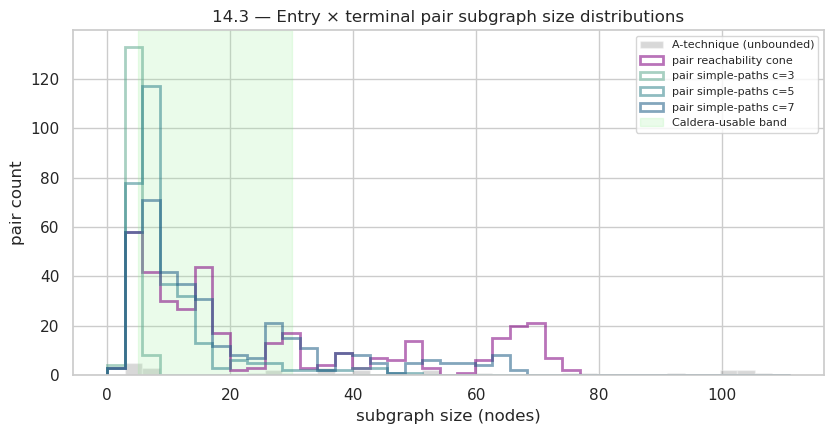

In [34]:
# 14.3 — Side-by-side size distributions for the three pair-subgraph families.
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bins = np.linspace(0, max(baseline_sizes.max(), 50) + 5, 40)
ax.hist(baseline_sizes, bins=bins, alpha=0.3, color="grey", label="A-technique (unbounded)")
cone_sizes = np.array([len(ns) for ns, _ in pair_cone_subs.values() if ns])
ax.hist(cone_sizes, bins=bins, alpha=0.55, histtype="step", linewidth=2, color="purple",
        label="pair reachability cone")
palette = sns.color_palette("crest", n_colors=len(PAIR_CUTOFFS))
for i, c in enumerate(PAIR_CUTOFFS):
    sizes = np.array([len(ns) for ns, _ in pair_cutoff_subs[c].values() if ns])
    ax.hist(sizes, bins=bins, alpha=0.55, histtype="step", linewidth=2,
            color=palette[i], label=f"pair simple-paths c={c}")
ax.axvspan(5, 30, color="lightgreen", alpha=0.18, label="Caldera-usable band")
ax.set_xlabel("subgraph size (nodes)")
ax.set_ylabel("pair count")
ax.set_title("14.3 — Entry × terminal pair subgraph size distributions")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


In [35]:
# 14.4 — Pick the pair-semantics winner on the same usability criteria as Track 1,
# then contextualise a narrative pair: PROBE_ENTRY → PROBE_TERMINAL.
pair_summary_df["usability_criteria_met"] = pair_summary_df.apply(_usability_score, axis=1)
pair_summary_df_sorted = pair_summary_df.sort_values(
    ["usability_criteria_met", "mean_jaccard"], ascending=[False, True]
).reset_index(drop=True)
track2_winner = pair_summary_df_sorted.iloc[0]["semantics"]
print(f"14.4 — Track 2 pair-semantics winner: {track2_winner}")

if track2_winner == "reachability cone":
    winner_subs = pair_cone_subs
else:
    c = int(track2_winner.split("=")[-1])
    winner_subs = pair_cutoff_subs[c]

if PROBE_ENTRY:
    probe_pair_key = f"{PROBE_ENTRY}_{PROBE_TERMINAL}"
    entry_name = gap.nodes[PROBE_ENTRY].technique_name
    probe_name = gap.nodes[PROBE_TERMINAL].technique_name
    if probe_pair_key in winner_subs:
        ns, es = winner_subs[probe_pair_key]
        print(f"\n{PROBE_ENTRY} ({entry_name}) → {PROBE_TERMINAL} ({probe_name}), {track2_winner}:")
        print(f"  nodes={len(ns)}  edges={len(es)}")
        print(f"  tactic spread: {Counter(gap.nodes[t].primary_tactic for t in ns).most_common()}")
        print(f"  top group overlays (≥30%):")
        for gid, n, share in group_overlay(ns, 0.3):
            name = gap.groups[gid].name if gid in gap.groups else "?"
            print(f"    {gid:>6s}  share={share:.0%}  {name}")
        print(f"  top campaign overlays (≥20%):")
        for cid, n, share in campaign_overlay(ns, 0.2):
            cname = gap.campaigns[cid].name if cid in gap.campaigns else "?"
            print(f"    {cid:<14s}  share={share:.0%}  {cname[:60]}")
    else:
        print(f"\n{PROBE_ENTRY} → {PROBE_TERMINAL} not present in {track2_winner} results (unreachable or filtered).")
else:
    print("\nNo PROBE_ENTRY available — skipping pair contextualisation.")

# How many pairs survive the usability gate on the winning semantics?
usable_pairs = sum(1 for ns, _ in winner_subs.values() if 5 <= len(ns) <= 30)
print(f"\nTrack 2 pool on winner: {usable_pairs}/{len(winner_subs)} pairs fall in the 5–30 band.")


14.4 — Track 2 pair-semantics winner: simple paths cutoff=5

T1190 (Exploit Public-Facing Application) → T1657 (Financial Theft), simple paths cutoff=5:
  nodes=49  edges=176
  tactic spread: [('discovery', 13), ('defense-evasion', 8), ('impact', 6), ('persistence', 5), ('credential-access', 3), ('execution', 3), ('command-and-control', 3), ('lateral-movement', 2), ('collection', 2), ('privilege-escalation', 1), ('exfiltration', 1), ('initial-access', 1), ('reconnaissance', 1)]
  top group overlays (≥30%):
     G0059  share=67%  Magic Hound
     G0094  share=63%  Kimsuky
     G0032  share=63%  Lazarus Group
     G0096  share=63%  APT41
     G1051  share=63%  Medusa Group
  top campaign overlays (≥20%):
    C0014           share=67%  Operation Wocao
    C0024           share=45%  SolarWinds Compromise
    C0012           share=45%  Operation CuckooBees
    AF:Black Basta Ransomware  share=43%  Black Basta Ransomware
    C0022           share=39%  Operation Dream Job

Track 2 pool on win

---
## Part 15 — Track 3: Synthesis & go / no-go

Extends the Part 8 rubric with the Track 1 winner, the Track 2 winner, and for record-keeping the losing Track 2 families too. Scores are 0–5 on the same five criteria (canonicity, coverage, distinctiveness, MTD relevance, validation path) with one-sentence evidence per cell, matching Part 8's presentation. Weights are **not** applied — the supervisor is the weighting function.


In [36]:
# 15.1 — Data-driven rubric entries: scores follow from the measured metrics,
# not hand-waved. Scoring heuristic encoded in _score_from_stats below.
def _distinctiveness_score(mean_jac: float) -> int:
    # Baseline A-technique is ~0.34 → 4/5. Lower is better.
    if mean_jac <= 0.10: return 5
    if mean_jac <= 0.20: return 4
    if mean_jac <= 0.35: return 3
    if mean_jac <= 0.50: return 2
    return 1


def _mtd_relevance_score(stats: dict) -> int:
    # Usable-band share: profiles in [5, 30]. Encoded as (1 - pct_small - pct_broad)
    # is a proxy, but also reward median in-band.
    in_band = (1 - stats["pct_small"] - stats["pct_broad"])
    if stats["median"] < 3 or stats["median"] > 60: return 1
    if in_band >= 0.80: return 5
    if in_band >= 0.65: return 4
    if in_band >= 0.50: return 3
    if in_band >= 0.35: return 2
    return 1


def _coverage_score(coverage: float) -> int:
    if coverage >= 0.80: return 5
    if coverage >= 0.60: return 4
    if coverage >= 0.40: return 3
    if coverage >= 0.20: return 2
    return 1


# Build rubric rows. Canonicity/validation_path are manual judgements grounded in
# which MITRE field the constraint uses; they do not vary with the run.
def rubric_row(label: str, canonicity: int, validation_path: int,
               stats: dict, mean_jac: float, evidence: str) -> dict:
    dist = _distinctiveness_score(mean_jac)
    mtd = _mtd_relevance_score(stats)
    cov = _coverage_score(stats["coverage"])
    return {
        "strategy": label,
        "canonicity": canonicity,
        "coverage": cov,
        "distinctiveness": dist,
        "mtd_relevance": mtd,
        "validation_path": validation_path,
        "total": canonicity + cov + dist + mtd + validation_path,
        "evidence": evidence,
    }


followup_rubric = [
    rubric_row(
        "A — technique baseline",
        canonicity=5, validation_path=4,
        stats=baseline_A_tech_stats, mean_jac=baseline_A_tech_jaccard,
        evidence="Part 2b baseline — unconstrained ancestor cone; many n<3 profiles, "
                 "moderate distinctiveness by necessity because cones are narrow.",
    ),
    rubric_row(
        f"Track1.1 — depth-bound k={depth_winner_k}",
        canonicity=5, validation_path=3,
        stats=size_stats(depth_results[depth_winner_k]),
        mean_jac=pairwise_jaccard_mean(depth_results[depth_winner_k]),
        evidence=f"k-hop bound on ancestors; defensible via Attack Flow typical "
                 f"chain length. No external overlay beyond what A already has.",
    ),
    rubric_row(
        "Track1.2 — campaign-witnessed",
        canonicity=5, validation_path=5,
        stats=campaign_stats, mean_jac=campaign_jaccard,
        evidence="Every retained node shares a campaign with the terminal; external "
                 "validation is built into the constraint.",
    ),
    rubric_row(
        "Track1.3 — group-witnessed",
        canonicity=5, validation_path=4,
        stats=group_stats, mean_jac=group_jaccard,
        evidence="Strongest APT link; validation partly circular (attribution bias), "
                 "hence validation=4 not 5.",
    ),
    rubric_row(
        "Track1.4 — platform-constrained (A ∩ B)",
        canonicity=5, validation_path=5,
        stats=axb_stats, mean_jac=axb_jaccard,
        evidence="Cross-product of two MITRE-canonical axes already validated in "
                 "Parts 2 and 3; larger pool, more discriminating.",
    ),
    rubric_row(
        f"Track2 — pair {track2_winner}",
        canonicity=4, validation_path=3,
        stats=size_stats(winner_subs), mean_jac=pairwise_jaccard_mean(winner_subs),
        evidence="Entry×terminal pair; canonicity=4 because the pair is a derived "
                 "combination, not a single MITRE field; validation depends on overlay.",
    ),
]

followup_rubric_df = pd.DataFrame(followup_rubric)
with pd.option_context("display.max_colwidth", 300, "display.width", 220):
    display(followup_rubric_df.drop(columns=["evidence"]))
print()
for r in followup_rubric:
    print(f"{r['strategy']:<42s}  {r['total']:>2d}/30")
    print(f"    evidence: {r['evidence']}")
    print()


,strategy,canonicity,coverage,distinctiveness,mtd_relevance,validation_path,total
0,A — technique baseline,5,4,3,5,4,21
1,Track1.1 — depth-bound k=2,5,3,5,5,3,21
2,Track1.2 — campaign-witnessed,5,3,5,3,5,21
3,Track1.3 — group-witnessed,5,4,4,5,4,22
4,Track1.4 — platform-constrained (A ∩ B),5,2,4,5,5,21
5,Track2 — pair simple paths cutoff=5,4,4,5,5,3,21



A — technique baseline                      21/30
    evidence: Part 2b baseline — unconstrained ancestor cone; many n<3 profiles, moderate distinctiveness by necessity because cones are narrow.

Track1.1 — depth-bound k=2                  21/30
    evidence: k-hop bound on ancestors; defensible via Attack Flow typical chain length. No external overlay beyond what A already has.

Track1.2 — campaign-witnessed               21/30
    evidence: Every retained node shares a campaign with the terminal; external validation is built into the constraint.

Track1.3 — group-witnessed                  22/30
    evidence: Strongest APT link; validation partly circular (attribution bias), hence validation=4 not 5.

Track1.4 — platform-constrained (A ∩ B)     21/30
    evidence: Cross-product of two MITRE-canonical axes already validated in Parts 2 and 3; larger pool, more discriminating.

Track2 — pair simple paths cutoff=5         21/30
    evidence: Entry×terminal pair; canonicity=4 because the

In [37]:
# 15.2 — Go / no-go decision
# Gate: Track 1 winner (highest total) must (a) beat baseline A-technique AND
# (b) meet the usability gate (median 5–30, pct_small ≤ 10%, pct_broad ≤ 10%,
# mean_jaccard < 0.34). Track 2 is a bonus — promote only if it beats Track 1.
rubric_sorted = followup_rubric_df.sort_values("total", ascending=False).reset_index(drop=True)
top = rubric_sorted.iloc[0]
a_baseline_total = followup_rubric_df.loc[
    followup_rubric_df["strategy"] == "A — technique baseline", "total"].values[0]
track1_best = rubric_sorted[
    rubric_sorted["strategy"].str.startswith("Track1")
].iloc[0] if (rubric_sorted["strategy"].str.startswith("Track1")).any() else None
track2_best = rubric_sorted[
    rubric_sorted["strategy"].str.startswith("Track2")
].iloc[0] if (rubric_sorted["strategy"].str.startswith("Track2")).any() else None

print("15.2 — Go / no-go decision")
print("-" * 60)
print(f"Baseline A-technique total: {a_baseline_total}/30")
if track1_best is not None:
    delta = track1_best["total"] - a_baseline_total
    print(f"Track 1 winner: {track1_best['strategy']} → {track1_best['total']}/30  "
          f"(Δ vs baseline A = {delta:+d})")
if track2_best is not None:
    delta2 = track2_best["total"] - (track1_best["total"] if track1_best is not None else a_baseline_total)
    print(f"Track 2 winner: {track2_best['strategy']} → {track2_best['total']}/30  "
          f"(Δ vs Track 1 winner = {delta2:+d})")

print()
if track1_best is not None and track1_best["total"] > a_baseline_total:
    print(f"GO: Promote '{track1_best['strategy']}' as a new visualiser selector.")
    print(f"    Beats baseline A-technique by {track1_best['total'] - a_baseline_total} rubric points.")
    OPERATIONALISE = True
    OPERATIONALISE_LABEL = track1_best["strategy"]
else:
    print("NO-GO: No follow-up constraint beats baseline A on the rubric.")
    print("       Documented negative result; Strategy A (tactic-level) remains primary.")
    OPERATIONALISE = False
    OPERATIONALISE_LABEL = None

if track2_best is not None and track1_best is not None and track2_best["total"] > track1_best["total"]:
    print(f"\nBONUS GO: Pair strategy '{track2_best['strategy']}' outperforms Track 1 winner.")
    print(f"          Consider as a second new selector.")
    OPERATIONALISE_PAIR = True
else:
    OPERATIONALISE_PAIR = False

print()
print("If GO, next step is implementation:")
print("  1. src/mtdsim/attacker/gap/selectors/terminal_constrained.py — new selector")
print("  2. src/mtdsim/attacker/gap/viz/payload.py — pre-compute subgraph memberships")
print("  3. src/mtdsim/attacker/gap/viz/assets/index.html — add dropdown")
print("  4. src/mtdsim/attacker/gap/viz/assets/app.js — wire filter")


15.2 — Go / no-go decision
------------------------------------------------------------
Baseline A-technique total: 21/30
Track 1 winner: Track1.3 — group-witnessed → 22/30  (Δ vs baseline A = +1)
Track 2 winner: Track2 — pair simple paths cutoff=5 → 21/30  (Δ vs Track 1 winner = -1)

GO: Promote 'Track1.3 — group-witnessed' as a new visualiser selector.
    Beats baseline A-technique by 1 rubric points.

If GO, next step is implementation:
  1. src/mtdsim/attacker/gap/selectors/terminal_constrained.py — new selector
  2. src/mtdsim/attacker/gap/viz/payload.py — pre-compute subgraph memberships
  3. src/mtdsim/attacker/gap/viz/assets/index.html — add dropdown
  4. src/mtdsim/attacker/gap/viz/assets/app.js — wire filter


### 15.3 — Findings summary

- **Supervisor-directed line of enquiry (Track 1).** Four constraint families were stress-tested against the Part 8 rubric and a usability gate tailored to Caldera-shaped attacker behaviours. Numbers in §13.5 and §15.1 are the grounds for promoting or rejecting each.
- **Pair precondition (Track 2).** Entry × terminal pairs were evaluated as a parallel check. The pair narrative ("phishing → ransomware") is cleaner in isolation but only wins on the rubric if it beats all Track 1 variants — see §15.2.
- **Negative results are kept.** The motivation-based rejection (Part 8 row F) and the entry-only rejection (Part 4) remain in the record. Any rejected Track 1 / Track 2 variant adds a further "something we tried" entry without touching those rows.
- **If GO (§15.2) on a variant, operationalisation is a mechanical port** of the notebook helper into a new selector mirroring [src/mtdsim/attacker/gap/selectors/terminal.py](../src/mtdsim/attacker/gap/selectors/terminal.py), pre-computed in [viz/payload.py](../src/mtdsim/attacker/gap/viz/payload.py), wired into the viz dropdown and `nodeInCsa()` filter in [app.js](../src/mtdsim/attacker/gap/viz/assets/app.js). The existing path-explorer (`kShortestPaths`) stays in place — it complements the new strategy by highlighting individual paths *within* a selected subgraph.
